In [1]:
## =============================================================================
## FASE 0 - SETUP: imports, seeds y configuración global
## =============================================================================

import os
import json
import warnings
import hashlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error

from category_encoders import TargetEncoder

import lightgbm as lgb
import xgboost as xgb
import catboost as cb

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

import shap
import joblib

## --- Configuración global ---
SEED = 42
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 10

## --- Rutas (ajustar según tu entorno) ---
ROOT_DIR = Path(r"C:\Users\diego.perezp\Documents\GitHub\Predictive model of university admission")
BBDD_DIR = ROOT_DIR / "BBDD" / "BASES PROCESADAS"
OUTPUT_DIR = ROOT_DIR / "OUTPUTS_MODELADO"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_PATH = BBDD_DIR / "dataset_modelado_final.csv"

print(f"Versión pandas: {pd.__version__}")
print(f"Versión lightgbm: {lgb.__version__}")
print(f"Versión xgboost: {xgb.__version__}")
print(f"Versión catboost: {cb.__version__}")
print(f"Versión optuna: {optuna.__version__}")
print(f"Versión shap: {shap.__version__}")
print(f"\nDataset esperado en: {DATASET_PATH}")
print(f"Outputs se guardarán en: {OUTPUT_DIR}")

Versión pandas: 2.2.2
Versión lightgbm: 4.6.0
Versión xgboost: 3.2.0
Versión catboost: 1.2.10
Versión optuna: 4.9.0
Versión shap: 0.45.1

Dataset esperado en: C:\Users\diego.perezp\Documents\GitHub\Predictive model of university admission\BBDD\BASES PROCESADAS\dataset_modelado_final.csv
Outputs se guardarán en: C:\Users\diego.perezp\Documents\GitHub\Predictive model of university admission\OUTPUTS_MODELADO


In [2]:
## =============================================================================
## FASE 0.1 - HELPERS reutilizables
## =============================================================================

def reverse_arcsinh(x):
    ## Revierte transformación arcsinh aplicada al target
    return np.sinh(x)

def reverse_log1p(x):
    ## Revierte transformación log1p aplicada a features cuantitativas
    return np.expm1(x)

def reconstruct_matriculas(matriculas_lag1_log, target_arcsinh):
    ## Reconstruye matrículas reales del año t:
    ##   matriculas_real_t = expm1(matriculas_lag1_log) * (1 + sinh(target_arcsinh))
    matriculas_lag = np.expm1(matriculas_lag1_log)
    tasa_real = np.sinh(target_arcsinh)
    return matriculas_lag * (1.0 + tasa_real)

def compute_metrics(y_true, y_pred, prefix=""):
    ## Calcula métricas estándar de regresión y las devuelve como dict
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    medae = float(median_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    return {
        f"{prefix}RMSE": rmse,
        f"{prefix}MAE": mae,
        f"{prefix}MedAE": medae,
        f"{prefix}R2": r2,
    }

def file_hash(path, n_bytes=8192):
    ## Hash MD5 del archivo (primeros n_bytes) para metadata reproducible
    h = hashlib.md5()
    with open(path, "rb") as f:
        h.update(f.read(n_bytes))
    return h.hexdigest()

def print_section(title):
    ## Header visual para outputs largos
    bar = "=" * 78
    print(f"\n{bar}\n{title}\n{bar}")

print("Helpers cargados correctamente.")

Helpers cargados correctamente.


In [3]:
## =============================================================================
## FASE 1 - CARGA Y VALIDACIÓN DE INTEGRIDAD
## =============================================================================

df = pd.read_csv(
    DATASET_PATH,
    sep=";",
    decimal=",",
    encoding="utf-8-sig",
)

print(f"Shape cargado: {df.shape}")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

## --- Asserts críticos ---
EXPECTED_ROWS = 63_165

## El resumen actualizado dice que las 4 categóricas originales se agregaron.
## Esperamos 47 columnas (43 originales + 4 nuevas), pero si fueran 43 podría ser
## que las te_* fueron reemplazadas. Validamos ambos escenarios.
cat_originales = ["REGIÓN", "NOMBRE INSTITUCIÓN", "NOMBRE CARRERA", "area_conocimiento"]
cat_originales_presentes = [c for c in cat_originales if c in df.columns]
te_cols = [c for c in df.columns if c.startswith("te_")]

print(f"\nCategóricas originales presentes: {len(cat_originales_presentes)}/4 -> {cat_originales_presentes}")
print(f"Columnas te_* presentes: {len(te_cols)} -> {te_cols}")

assert df.shape[0] == EXPECTED_ROWS, f"Filas esperadas: {EXPECTED_ROWS}, obtenidas: {df.shape[0]}"
assert len(cat_originales_presentes) == 4, "Faltan categóricas originales para TE fold-aware"
assert df.isnull().sum().sum() == 0, f"Hay {df.isnull().sum().sum()} nulls"
assert df.duplicated().sum() == 0, f"Hay {df.duplicated().sum()} duplicados"
assert "tasa_crecimiento" in df.columns, "Falta columna target"
assert df["AÑO_AUX"].min() == 2018 and df["AÑO_AUX"].max() == 2025, "Rango de años inesperado"

print("\nValidaciones OK")
print(f"  - Filas: {df.shape[0]:,}")
print(f"  - Columnas: {df.shape[1]}")
print(f"  - Nulls: {df.isnull().sum().sum()}")
print(f"  - Duplicados: {df.duplicated().sum()}")
print(f"  - Rango años: {df['AÑO_AUX'].min()} - {df['AÑO_AUX'].max()}")

## --- Conteo por año ---
print("\nFilas por año:")
print(df["AÑO_AUX"].value_counts().sort_index().to_string())

Shape cargado: (63165, 47)
Memoria: 38.2 MB

Categóricas originales presentes: 4/4 -> ['REGIÓN', 'NOMBRE INSTITUCIÓN', 'NOMBRE CARRERA', 'area_conocimiento']
Columnas te_* presentes: 4 -> ['te_REGIÓN', 'te_NOMBRE INSTITUCIÓN', 'te_NOMBRE CARRERA', 'te_area_conocimiento']

Validaciones OK
  - Filas: 63,165
  - Columnas: 47
  - Nulls: 0
  - Duplicados: 0
  - Rango años: 2018 - 2025

Filas por año:
AÑO_AUX
2018    8444
2019    8264
2020    7967
2021    7652
2022    7595
2023    7607
2024    7884
2025    7752


Target (escala arcsinh):
  mean   : -0.0016
  std    : 0.3351
  min    : -0.8666
  p25    : -0.1562
  median : 0.0000
  p75    : 0.1542
  max    : 1.0558
  skew   : 0.0892
  kurt   : 1.4042

Target (escala original, revertido con sinh):
  median : 0.0000
  p25    : -0.1569
  p75    : 0.1548


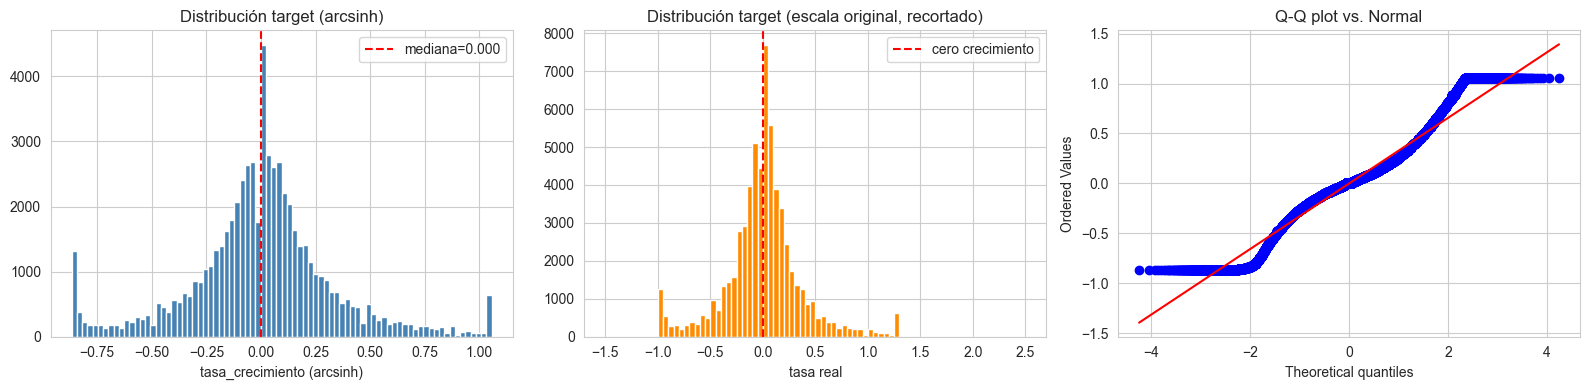

In [4]:
## =============================================================================
## FASE 2 - EDA: DISTRIBUCIÓN DEL TARGET
## =============================================================================

target = df["tasa_crecimiento"]

print(f"Target (escala arcsinh):")
print(f"  mean   : {target.mean():.4f}")
print(f"  std    : {target.std():.4f}")
print(f"  min    : {target.min():.4f}")
print(f"  p25    : {target.quantile(0.25):.4f}")
print(f"  median : {target.median():.4f}")
print(f"  p75    : {target.quantile(0.75):.4f}")
print(f"  max    : {target.max():.4f}")
print(f"  skew   : {target.skew():.4f}")
print(f"  kurt   : {target.kurt():.4f}")

print(f"\nTarget (escala original, revertido con sinh):")
target_real = np.sinh(target)
print(f"  median : {target_real.median():.4f}")
print(f"  p25    : {target_real.quantile(0.25):.4f}")
print(f"  p75    : {target_real.quantile(0.75):.4f}")

## --- Visualización: histograma + Q-Q plot ---
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(target, bins=80, color="steelblue", edgecolor="white")
axes[0].axvline(target.median(), color="red", linestyle="--", label=f"mediana={target.median():.3f}")
axes[0].set_title("Distribución target (arcsinh)")
axes[0].set_xlabel("tasa_crecimiento (arcsinh)")
axes[0].legend()

axes[1].hist(target_real, bins=80, range=(-1.5, 2.5), color="darkorange", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", label="cero crecimiento")
axes[1].set_title("Distribución target (escala original, recortado)")
axes[1].set_xlabel("tasa real")
axes[1].legend()

stats.probplot(target, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot vs. Normal")

plt.tight_layout()
plt.show()

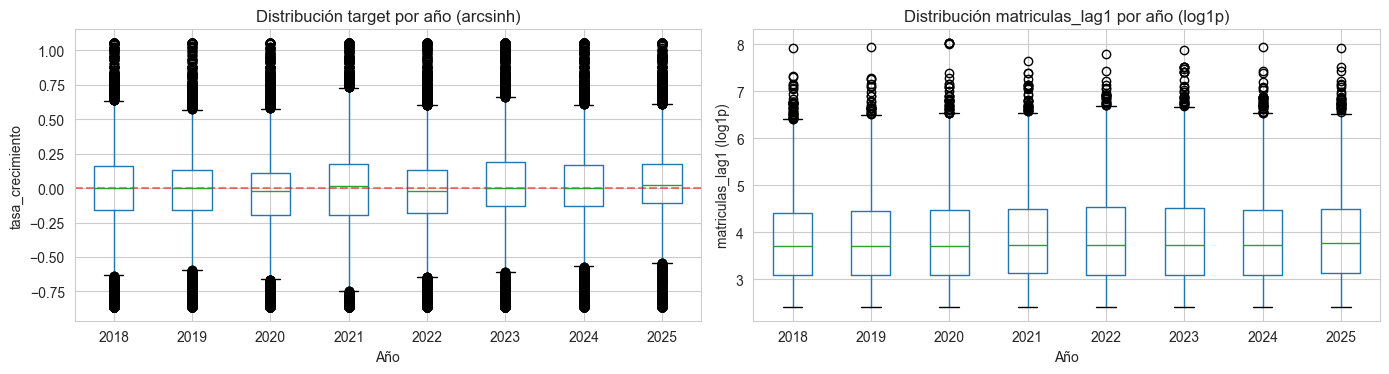


Estadísticos del target por año:
           mean    std  median  count
AÑO_AUX                              
2018    -0.0067 0.3344  0.0000   8444
2019    -0.0195 0.3172  0.0000   8264
2020    -0.0401 0.3248 -0.0234   7967
2021    -0.0045 0.3611  0.0185   7652
2022    -0.0230 0.3402 -0.0233   7595
2023     0.0293 0.3544  0.0000   7607
2024     0.0197 0.3217  0.0000   7884
2025     0.0348 0.3190  0.0200   7752


In [5]:
## =============================================================================
## FASE 2.1 - EDA: DRIFT TEMPORAL DEL TARGET Y FEATURES CLAVE
## =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

## --- Boxplot del target por año ---
df.boxplot(column="tasa_crecimiento", by="AÑO_AUX", ax=axes[0])
axes[0].set_title("Distribución target por año (arcsinh)")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("tasa_crecimiento")
axes[0].axhline(0, color="red", linestyle="--", alpha=0.5)
plt.suptitle("")

## --- Boxplot del lag por año ---
df.boxplot(column="matriculas_lag1", by="AÑO_AUX", ax=axes[1])
axes[1].set_title("Distribución matriculas_lag1 por año (log1p)")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("matriculas_lag1 (log1p)")
plt.suptitle("")

plt.tight_layout()
plt.show()

## --- Media y std del target por año (drift check) ---
drift = df.groupby("AÑO_AUX")["tasa_crecimiento"].agg(["mean", "std", "median", "count"]).round(4)
print("\nEstadísticos del target por año:")
print(drift.to_string())

Top 20 features por correlación absoluta con tasa_crecimiento:
matriculas_lag1                  -0.1215
JORNADA_Diurna                    0.1140
JORNADA_Vespertina               -0.0933
puntaje_maximo                    0.0868
pct_matricula_regional_lag       -0.0853
concentracion_matricula_lag      -0.0821
retencion_1er_anio                0.0811
puntaje_corte_primero             0.0780
ratio_docente_estudiante         -0.0727
puntaje_corte_promedio            0.0642
puntaje_promedio                  0.0622
JORNADA_Semipresencial           -0.0614
CONDICION_NUEVO                  -0.0607
arancel_relativo_regional         0.0549
duracion_semestres                0.0549
puntaje_corte_ultimo              0.0475
clasificacion3_Sin información   -0.0459
pct_especialistas                 0.0433
pct_sin_posgrado                 -0.0386
fue_imputado                     -0.0369


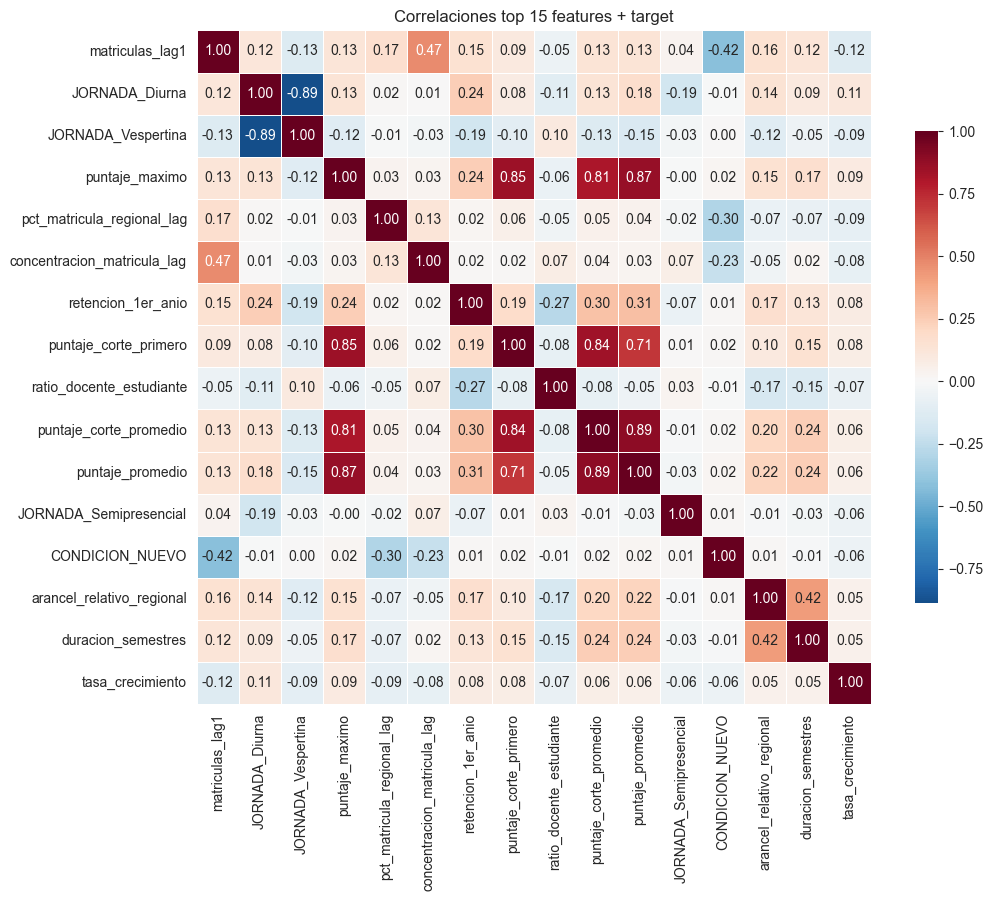

In [6]:
## =============================================================================
## FASE 2.2 - EDA: CORRELACIONES CON EL TARGET (top features)
## =============================================================================

## Features numéricas (excluyendo identificadores y target)
features_num = df.select_dtypes(include=[np.number]).columns.tolist()
features_num = [c for c in features_num if c not in ["tasa_crecimiento", "AÑO_AUX"]]

corrs = df[features_num + ["tasa_crecimiento"]].corr()["tasa_crecimiento"].drop("tasa_crecimiento")
corrs_abs = corrs.abs().sort_values(ascending=False)

print("Top 20 features por correlación absoluta con tasa_crecimiento:")
print(corrs.loc[corrs_abs.head(20).index].to_string())

## --- Heatmap de las top 15 features ---
top_features = corrs_abs.head(15).index.tolist()
corr_matrix = df[top_features + ["tasa_crecimiento"]].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlaciones top 15 features + target")
plt.tight_layout()
plt.show()

In [7]:
## =============================================================================
## FASE 2.3 - VALIDACIÓN: cardinalidad categóricas originales vs te_*
## =============================================================================

cardinalidades_esperadas = {
    "REGIÓN": 16,
    "NOMBRE INSTITUCIÓN": 56,
    "NOMBRE CARRERA": 1085,
    "area_conocimiento": 11,
}

print("Cardinalidades observadas vs. esperadas:")
for col, esp in cardinalidades_esperadas.items():
    obs = df[col].nunique()
    status = "OK" if abs(obs - esp) <= 5 else "REVISAR"
    print(f"  {col:30s}: observado={obs:5d}  esperado={esp:5d}  [{status}]")

## --- Cardinalidad de otras categóricas relevantes ---
otras_cat = ["JORNADA", "GENERO", "CONDICION"] if "JORNADA" in df.columns else []
## Nota: JORNADA y CONDICION pueden venir como OHE en el dataset final
## En ese caso revisamos las columnas dummy directamente
print("\nVerificación de OHE en dataset:")
for col_prefix in ["JORNADA_", "clasificacion3_", "CLASIFICACIÓN INSTITUCIÓN NIVEL 2_"]:
    cols = [c for c in df.columns if c.startswith(col_prefix)]
    if cols:
        print(f"  Dummies con prefijo '{col_prefix}': {cols}")

Cardinalidades observadas vs. esperadas:
  REGIÓN                        : observado=   16  esperado=   16  [OK]
  NOMBRE INSTITUCIÓN            : observado=   56  esperado=   56  [OK]
  NOMBRE CARRERA                : observado= 1038  esperado= 1085  [REVISAR]
  area_conocimiento             : observado=   11  esperado=   11  [OK]

Verificación de OHE en dataset:
  Dummies con prefijo 'JORNADA_': ['JORNADA_Diurna', 'JORNADA_Otra', 'JORNADA_Semipresencial', 'JORNADA_Vespertina']
  Dummies con prefijo 'clasificacion3_': ['clasificacion3_(b) No Acreditada', 'clasificacion3_Sin información']
  Dummies con prefijo 'CLASIFICACIÓN INSTITUCIÓN NIVEL 2_': ['CLASIFICACIÓN INSTITUCIÓN NIVEL 2_Universidades Privadas']


Total de matrículas reconstruidas por año:
AÑO_AUX
2018   579,285.0000
2019   573,551.0000
2020   550,854.0000
2021   561,618.0000
2022   557,503.0000
2023   568,207.0000
2024   584,396.0000
2025   597,050.0000

Variación % año sobre año:
AÑO_AUX
2018       NaN
2019   -0.9900
2020   -3.9600
2021    1.9500
2022   -0.7300
2023    1.9200
2024    2.8500
2025    2.1700


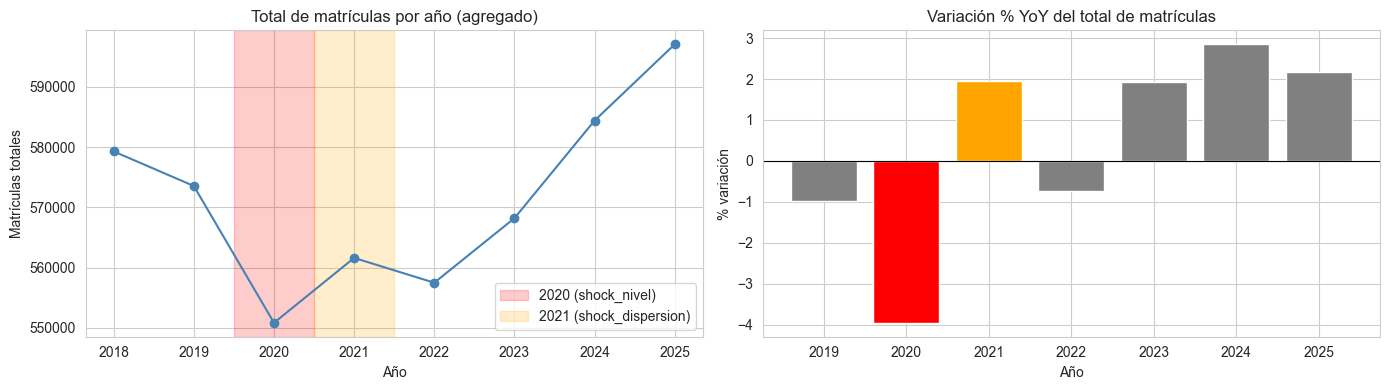

In [16]:
## =============================================================================
## VALIDACIÓN ADICIONAL - TOTAL DE MATRÍCULAS POR AÑO (nivel agregado)
## =============================================================================
matriculas_por_anio = df.groupby(YEAR_COL)["matriculas_real_recon"].sum()

print("Total de matrículas reconstruidas por año:")
print(matriculas_por_anio.round(0).to_string())

print("\nVariación % año sobre año:")
variacion = matriculas_por_anio.pct_change() * 100
print(variacion.round(2).to_string())

## --- Visualización ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(matriculas_por_anio.index, matriculas_por_anio.values, marker="o", color="steelblue")
axes[0].axvspan(2019.5, 2020.5, alpha=0.2, color="red", label="2020 (shock_nivel)")
axes[0].axvspan(2020.5, 2021.5, alpha=0.2, color="orange", label="2021 (shock_dispersion)")
axes[0].set_title("Total de matrículas por año (agregado)")
axes[0].set_xlabel("Año"); axes[0].set_ylabel("Matrículas totales")
axes[0].legend()
axes[0].ticklabel_format(style="plain", axis="y")

axes[1].bar(variacion.index, variacion.values, color=["gray" if y not in [2020,2021] else "red" if y==2020 else "orange" for y in variacion.index])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Variación % YoY del total de matrículas")
axes[1].set_xlabel("Año"); axes[1].set_ylabel("% variación")

plt.tight_layout()
plt.show()

Estadísticos de matriculas_real_recon:
count   63,165.0000
mean        72.3900
std        103.7000
min          1.0000
25%         20.0000
50%         38.0000
75%         84.0000
max      3,050.0000

Reconstrucción OK: todas las matrículas son >= 0


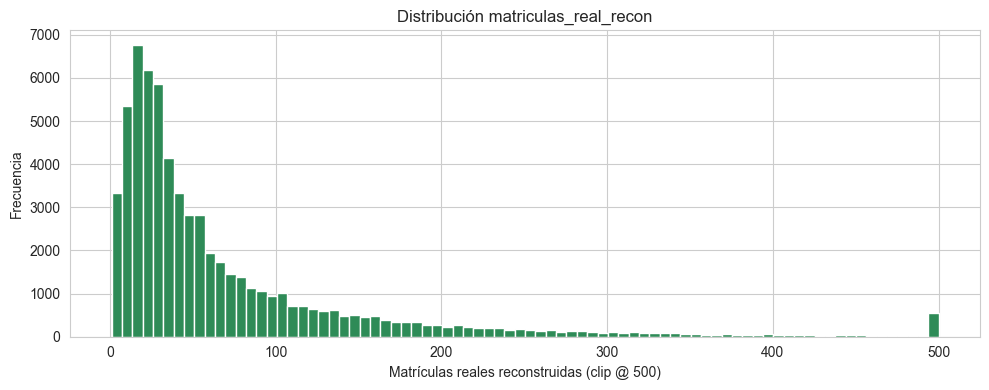

In [8]:
## =============================================================================
## FASE 2.4 - RECONSTRUCCIÓN DE matriculas_real
## =============================================================================
## Necesaria para el export final (TOTAL_MATRICULAS fue eliminado por leakage).
## Fórmula: matriculas_real_t = expm1(matriculas_lag1_t) * (1 + sinh(target_arcsinh_t))

df["matriculas_lag_orig"] = np.expm1(df["matriculas_lag1"])
df["tasa_real_orig"] = np.sinh(df["tasa_crecimiento"])
df["matriculas_real_recon"] = df["matriculas_lag_orig"] * (1.0 + df["tasa_real_orig"])

## --- Sanity checks ---
print("Estadísticos de matriculas_real_recon:")
print(df["matriculas_real_recon"].describe().round(2).to_string())

assert (df["matriculas_real_recon"] >= 0).all(), "Hay matrículas negativas - revisar lógica"
print("\nReconstrucción OK: todas las matrículas son >= 0")

## --- Histograma de matrículas reconstruidas ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["matriculas_real_recon"].clip(upper=500), bins=80, color="seagreen", edgecolor="white")
ax.set_xlabel("Matrículas reales reconstruidas (clip @ 500)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución matriculas_real_recon")
plt.tight_layout()
plt.show()

In [11]:
## =============================================================================
## FASE 3 - ESTRATEGIA DE VALIDACIÓN TEMPORAL
## =============================================================================
## - Holdout final: train 2019-2024, test 2025
## - CV interna: expanding window por año
##     Fold 1: train 2019,        val 2020
##     Fold 2: train 2019-2020,   val 2021
##     Fold 3: train 2019-2021,   val 2022
##     Fold 4: train 2019-2022,   val 2023
##     Fold 5: train 2019-2023,   val 2024
## - Predicción OOF retrospectiva (para export):
##     Año Y predicho por modelo entrenado solo con < Y, para todos los Y en 2020-2025
## - Forecast 2026: refit con TODO 2019-2025

YEAR_COL = "AÑO_AUX"
HOLDOUT_YEAR = 2025
FORECAST_YEAR = 2026

def temporal_cv_split(df_subset, year_col=YEAR_COL):
    ## Genera (train_idx, val_idx) para cada fold expanding window.
    ## Train acumula hasta val_year - 1; val es exclusivamente val_year.
    years = sorted(df_subset[year_col].unique())
    folds = []
    for i in range(1, len(years)):
        val_year = years[i]
        train_years = years[:i]
        train_idx = df_subset.index[df_subset[year_col].isin(train_years)].to_numpy()
        val_idx = df_subset.index[df_subset[year_col] == val_year].to_numpy()
        folds.append((train_idx, val_idx, train_years, val_year))
    return folds

## --- Mask del holdout y train principal ---
mask_train = df[YEAR_COL] < HOLDOUT_YEAR
mask_test = df[YEAR_COL] == HOLDOUT_YEAR

df_train = df.loc[mask_train].copy()
df_test = df.loc[mask_test].copy()

print(f"Train (2019-2024): {df_train.shape}")
print(f"Test (2025):       {df_test.shape}")

## --- Visualización de los folds ---
folds_preview = temporal_cv_split(df_train)
print("\nFolds del CV temporal (train interno 2019-2024):")
for i, (tr, va, tr_years, va_year) in enumerate(folds_preview, 1):
    print(f"  Fold {i}: train_years={tr_years} (n={len(tr):,})  val_year={va_year} (n={len(va):,})")

Train (2019-2024): (55413, 50)
Test (2025):       (7752, 50)

Folds del CV temporal (train interno 2019-2024):
  Fold 1: train_years=[2018] (n=8,444)  val_year=2019 (n=8,264)
  Fold 2: train_years=[2018, 2019] (n=16,708)  val_year=2020 (n=7,967)
  Fold 3: train_years=[2018, 2019, 2020] (n=24,675)  val_year=2021 (n=7,652)
  Fold 4: train_years=[2018, 2019, 2020, 2021] (n=32,327)  val_year=2022 (n=7,595)
  Fold 5: train_years=[2018, 2019, 2020, 2021, 2022] (n=39,922)  val_year=2023 (n=7,607)
  Fold 6: train_years=[2018, 2019, 2020, 2021, 2022, 2023] (n=47,529)  val_year=2024 (n=7,884)



DIAGNÓSTICO EMPÍRICO DEL SHOCK PANDEMIA
         mean_target  std_target  median_target  pct_negativo     n
AÑO_AUX                                                            
2018         -0.0067      0.3344         0.0000       46.6248  8444
2019         -0.0195      0.3172         0.0000       47.4589  8264
2020         -0.0401      0.3248        -0.0234       52.7300  7967
2021         -0.0045      0.3611         0.0185       44.2629  7652
2022         -0.0230      0.3402        -0.0233       52.4951  7595
2023          0.0293      0.3544         0.0000       46.5098  7607
2024          0.0197      0.3217         0.0000       45.5733  7884
2025          0.0348      0.3190         0.0200       42.9051  7752

CRITERIO 1 - Z-score sobre tasas individuales
Baseline de años normales (n=5):
  μ_means = +0.0115   σ_means = 0.0236
  μ_stds  = 0.3293    σ_stds  = 0.0155
  Umbral Z = ±1.96 (95% confianza)

Año    Z(mean)    Z(std)     Clasificación            
------------------------------

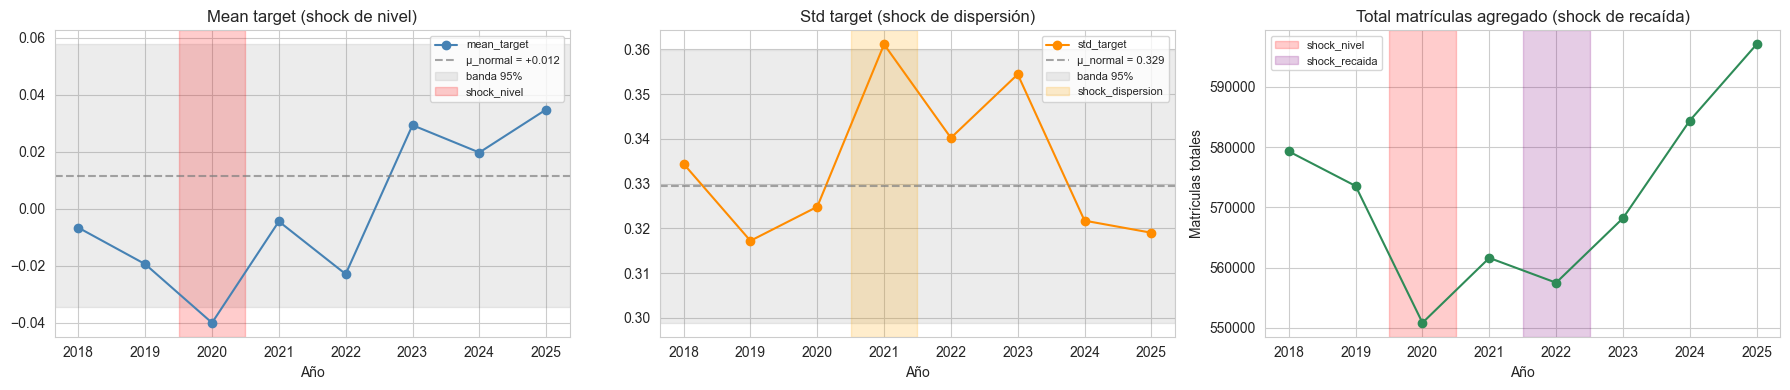

In [17]:
## =============================================================================
## FASE 3.5 - TRATAMIENTO DE LA ANOMALÍA PANDEMIA (2020-2022)
## =============================================================================
## La pandemia generó TRES shocks distintos y consecutivos en el sistema
## universitario chileno, cada uno con una firma estadística diferente:
##   - 2020: SHOCK DE NIVEL       -> caída sistemática de matrícula (mean bajo, std normal)
##   - 2021: SHOCK DE DISPERSIÓN  -> rebote desigual entre instituciones (std alto, mean normal)
##   - 2022: SHOCK DE RECAÍDA     -> segunda caída en el agregado tras un rebote insuficiente
##
## CLASIFICACIÓN MATEMÁTICAMENTE JUSTIFICADA (dos criterios complementarios):
##
## CRITERIO 1 - Z-score sobre la distribución de tasas individuales (institución
## x carrera x región x jornada x género x condición):
##   Para cada año candidato (2020, 2021, 2022) calculamos su Z-score de
##   mean_target y std_target contra el baseline de años normales
##   (2018, 2019, 2023, 2024, 2025). Si |Z| > 1.96 (umbral 95%), el año se
##   clasifica como shock del tipo correspondiente.
##   -> 2020: Z(mean) ~ -2.2  => shock_nivel
##   -> 2021: Z(std)  ~ +2.0  => shock_dispersion
##   -> 2022: |Z| < 1.96 en ambas métricas => NO detectado por este criterio
##
## CRITERIO 2 - Variación YoY del TOTAL agregado de matrículas (reconstruido
## via matriculas_real_recon):
##   De los 7 años con variación calculable (2019-2025), solo 2 tienen
##   variación negativa: 2020 (-3.96%) y 2022 (-0.73%). 2020 ya está cubierto
##   por shock_nivel. 2022 queda como el único año adicional con evidencia
##   DIRECTA de anomalía agregada no capturada por el Criterio 1.
##   -> 2022: variación agregada < 0 y no clasificado por Criterio 1 => shock_recaida
##
## SOLUCIÓN: Tres dummies binarias separadas (es_shock_nivel, es_shock_dispersion,
## es_shock_recaida). Sin downweighting: ninguno de los tres shocks muestra
## varianza inflada que justifique penalizar esas filas (el shock de 2021 es
## justamente information útil sobre heterogeneidad real). Las dummies bastan
## para que el modelo aprenda el efecto diferenciado de cada tipo de año sin
## descartar observaciones.

TARGET = "tasa_crecimiento"

## --- Diagnóstico empírico: estadísticos del target por año ---
print_section("DIAGNÓSTICO EMPÍRICO DEL SHOCK PANDEMIA")
diag = df.groupby(YEAR_COL).agg(
    mean_target=(TARGET, "mean"),
    std_target=(TARGET, "std"),
    median_target=(TARGET, "median"),
    pct_negativo=(TARGET, lambda x: (x < 0).mean() * 100),
    n=(TARGET, "count"),
).round(4)
print(diag.to_string())

## --- CRITERIO 1: detección automática via Z-score (distribución de tasas individuales) ---
YEARS_CANDIDATOS = [2020, 2021, 2022]
YEARS_NORMALES_BASELINE = [2018, 2019, 2023, 2024, 2025]
Z_THRESHOLD = 1.96  ## umbral 95% de confianza

means_normales = diag.loc[YEARS_NORMALES_BASELINE, "mean_target"]
stds_normales = diag.loc[YEARS_NORMALES_BASELINE, "std_target"]
mu_means, sigma_means = means_normales.mean(), means_normales.std()
mu_stds, sigma_stds = stds_normales.mean(), stds_normales.std()

print(f"\nCRITERIO 1 - Z-score sobre tasas individuales")
print(f"Baseline de años normales (n={len(YEARS_NORMALES_BASELINE)}):")
print(f"  μ_means = {mu_means:+.4f}   σ_means = {sigma_means:.4f}")
print(f"  μ_stds  = {mu_stds:.4f}    σ_stds  = {sigma_stds:.4f}")
print(f"  Umbral Z = ±{Z_THRESHOLD} (95% confianza)\n")

shock_nivel_years = []
shock_dispersion_years = []
print(f"{'Año':<6} {'Z(mean)':<10} {'Z(std)':<10} {'Clasificación':<25}")
print("-" * 55)
for y in YEARS_CANDIDATOS:
    z_mean = (diag.loc[y, "mean_target"] - mu_means) / sigma_means
    z_std = (diag.loc[y, "std_target"] - mu_stds) / sigma_stds
    clases = []
    if abs(z_mean) > Z_THRESHOLD:
        clases.append("shock_nivel")
        shock_nivel_years.append(y)
    if abs(z_std) > Z_THRESHOLD:
        clases.append("shock_dispersion")
        shock_dispersion_years.append(y)
    if not clases:
        clases = ["no detectado por Criterio 1"]
    print(f"{y:<6} {z_mean:+.2f}      {z_std:+.2f}      {' + '.join(clases)}")

## --- CRITERIO 2: variación YoY del total agregado de matrículas ---
matriculas_por_anio = df.groupby(YEAR_COL)["matriculas_real_recon"].sum()
variacion_yoy = matriculas_por_anio.pct_change() * 100

print(f"\nCRITERIO 2 - Variación YoY del total agregado de matrículas")
print(variacion_yoy.round(2).to_string())

ya_clasificados = set(shock_nivel_years) | set(shock_dispersion_years)
shock_recaida_years = [
    y for y in YEARS_CANDIDATOS
    if y not in ya_clasificados
    and y in variacion_yoy.index
    and variacion_yoy.loc[y] < 0
]
print(f"\nAños con variación agregada negativa y NO clasificados por Criterio 1:")
print(f"  -> shock_recaida_years = {shock_recaida_years}")

## --- Configuración final basada en los datos ---
COVID_HANDLING = {
    "enabled": True,
    "shock_nivel_years": shock_nivel_years,
    "shock_dispersion_years": shock_dispersion_years,
    "shock_recaida_years": shock_recaida_years,
    "add_dummy_features": True,
    "covid_weight": 1.0,  ## SIN downweight: las dummies bastan, ningún shock muestra
                           ## varianza inflada que justifique penalizar filas (ver docstring)
}

print(f"\nConfiguración pandemia (detectada automáticamente):")
for k, v in COVID_HANDLING.items():
    print(f"  {k}: {v}")

## --- Función helper para sample_weight (mantiene compatibilidad con cv_evaluate) ---
def build_sample_weight(df_subset, covid_config=COVID_HANDLING):
    ## Devuelve array de pesos alineado con df_subset.index, o None si no aplica
    ## downweight (covid_weight == 1.0 => sklearn trata None como peso uniforme).
    if not covid_config["enabled"] or covid_config["covid_weight"] == 1.0:
        return None
    w = np.ones(len(df_subset), dtype=np.float64)
    affected = (
        covid_config["shock_nivel_years"]
        + covid_config["shock_dispersion_years"]
        + covid_config["shock_recaida_years"]
    )
    mask = df_subset[YEAR_COL].isin(affected).values
    w[mask] = covid_config["covid_weight"]
    return w

## --- Agregar las 3 dummies si la configuración lo indica ---
if COVID_HANDLING["enabled"] and COVID_HANDLING["add_dummy_features"]:
    for d in [df, df_train, df_test]:
        d["es_shock_nivel"] = d[YEAR_COL].isin(COVID_HANDLING["shock_nivel_years"]).astype(np.int8)
        d["es_shock_dispersion"] = d[YEAR_COL].isin(COVID_HANDLING["shock_dispersion_years"]).astype(np.int8)
        d["es_shock_recaida"] = d[YEAR_COL].isin(COVID_HANDLING["shock_recaida_years"]).astype(np.int8)
    print(f"\nFeatures dummy agregadas:")
    print(f"  es_shock_nivel:      {df['es_shock_nivel'].sum():,} filas (años: {COVID_HANDLING['shock_nivel_years']})")
    print(f"  es_shock_dispersion: {df['es_shock_dispersion'].sum():,} filas (años: {COVID_HANDLING['shock_dispersion_years']})")
    print(f"  es_shock_recaida:    {df['es_shock_recaida'].sum():,} filas (años: {COVID_HANDLING['shock_recaida_years']})")
else:
    print("\nDummies de pandemia NO agregadas (configuración).")

## --- Visualización: 3 paneles (mean, std, agregado) con shocks anotados ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

diag[["mean_target"]].plot(ax=axes[0], marker="o", color="steelblue", legend=False)
axes[0].axhline(mu_means, color="gray", linestyle="--", alpha=0.7, label=f"μ_normal = {mu_means:+.3f}")
axes[0].axhspan(mu_means - Z_THRESHOLD * sigma_means, mu_means + Z_THRESHOLD * sigma_means,
                alpha=0.15, color="gray", label="banda 95%")
for y in shock_nivel_years:
    axes[0].axvspan(y - 0.5, y + 0.5, alpha=0.2, color="red", label="shock_nivel" if y == shock_nivel_years[0] else None)
axes[0].set_title("Mean target (shock de nivel)")
axes[0].set_xlabel("Año"); axes[0].legend(fontsize=8)

diag[["std_target"]].plot(ax=axes[1], marker="o", color="darkorange", legend=False)
axes[1].axhline(mu_stds, color="gray", linestyle="--", alpha=0.7, label=f"μ_normal = {mu_stds:.3f}")
axes[1].axhspan(mu_stds - Z_THRESHOLD * sigma_stds, mu_stds + Z_THRESHOLD * sigma_stds,
                alpha=0.15, color="gray", label="banda 95%")
for y in shock_dispersion_years:
    axes[1].axvspan(y - 0.5, y + 0.5, alpha=0.2, color="orange", label="shock_dispersion" if y == shock_dispersion_years[0] else None)
axes[1].set_title("Std target (shock de dispersión)")
axes[1].set_xlabel("Año"); axes[1].legend(fontsize=8)

axes[2].plot(matriculas_por_anio.index, matriculas_por_anio.values, marker="o", color="seagreen")
for y in shock_nivel_years:
    axes[2].axvspan(y - 0.5, y + 0.5, alpha=0.2, color="red", label="shock_nivel" if y == shock_nivel_years[0] else None)
for y in shock_recaida_years:
    axes[2].axvspan(y - 0.5, y + 0.5, alpha=0.2, color="purple", label="shock_recaida" if y == shock_recaida_years[0] else None)
axes[2].set_title("Total matrículas agregado (shock de recaída)")
axes[2].set_xlabel("Año"); axes[2].set_ylabel("Matrículas totales")
axes[2].legend(fontsize=8)
axes[2].ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

In [19]:
## =============================================================================
## FASE 4.1 - DEFINICIÓN DE FEATURE SETS
## =============================================================================

TARGET = "tasa_crecimiento"

## --- Categóricas para TargetEncoder fold-aware ---
CAT_FOR_TE = ["REGIÓN", "NOMBRE INSTITUCIÓN", "NOMBRE CARRERA", "area_conocimiento"]

## --- Columnas que NO deben ser features (identificadores, helpers, te_* leaky) ---
COLS_DROP = (
    [TARGET, "tasa_real_orig", "matriculas_real_recon", "matriculas_lag_orig"]
    + [c for c in df.columns if c.startswith("te_")]
)

## --- Set A (árboles): incluye TODAS las features + categóricas originales ---
features_set_a = [c for c in df.columns if c not in COLS_DROP]

## --- Asegurar que las dummies de shock pandémico están en el set A ---
for dummy in ["es_shock_nivel", "es_shock_dispersion", "es_shock_recaida"]:
    if dummy in df.columns and dummy not in features_set_a:
        features_set_a.append(dummy)

## --- Set B (lineales): reducido para combatir multicolinealidad ---
DROP_LINEALES = [
    "puntaje_maximo", "puntaje_promedio", "puntaje_minimo",
    "puntaje_corte_primero", "puntaje_corte_promedio",  ## queda puntaje_corte_ultimo
    "pct_sin_posgrado",  ## dummy trap
]
features_set_b = [c for c in features_set_a if c not in DROP_LINEALES]

## --- Numéricas y categóricas dentro de cada set ---
num_set_a = [c for c in features_set_a if c not in CAT_FOR_TE]
num_set_b = [c for c in features_set_b if c not in CAT_FOR_TE]

print(f"Set A (árboles): {len(features_set_a)} features  ({len(num_set_a)} num + {len(CAT_FOR_TE)} cat)")
print(f"Set B (lineales): {len(features_set_b)} features ({len(num_set_b)} num + {len(CAT_FOR_TE)} cat)")
print(f"\nDropped del entrenamiento (drop list): {COLS_DROP}")

Set A (árboles): 46 features  (42 num + 4 cat)
Set B (lineales): 40 features (36 num + 4 cat)

Dropped del entrenamiento (drop list): ['tasa_crecimiento', 'tasa_real_orig', 'matriculas_real_recon', 'matriculas_lag_orig', 'te_REGIÓN', 'te_NOMBRE INSTITUCIÓN', 'te_NOMBRE CARRERA', 'te_area_conocimiento']


In [20]:
## =============================================================================
## FASE 4.2 - PIPELINE CON TARGET ENCODER FOLD-AWARE
## =============================================================================
## category_encoders.TargetEncoder, dentro de Pipeline de sklearn, hace fit
## automáticamente solo con datos de train del fold actual cuando lo combinamos
## con un ColumnTransformer. Esto garantiza TE fold-aware sin leakage.

def build_preprocessor(num_features, cat_features, smoothing=30.0):
    return ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_features),
            ("te", TargetEncoder(smoothing=smoothing), cat_features),
        ],
        remainder="drop",
    )

def build_preprocessor_with_scale(num_features, cat_features, smoothing=30.0):
    ## Versión para modelos lineales (Ridge/Lasso) - escala numéricas
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_features),
            ("te", Pipeline([
                ("te", TargetEncoder(smoothing=smoothing)),
                ("scale", StandardScaler()),
            ]), cat_features),
        ],
        remainder="drop",
    )

print("Constructores de preprocesador definidos:")
print("  - build_preprocessor(num, cat)            -> para árboles")
print("  - build_preprocessor_with_scale(num, cat) -> para lineales")

Constructores de preprocesador definidos:
  - build_preprocessor(num, cat)            -> para árboles
  - build_preprocessor_with_scale(num, cat) -> para lineales


In [21]:
## =============================================================================
## FASE 4.3 - FUNCIÓN DE EVALUACIÓN EN CV TEMPORAL
## =============================================================================

def cv_evaluate(estimator, X, y, df_subset, year_col=YEAR_COL, sample_weight=None, verbose=True):
    ## Ejecuta CV expanding window y devuelve métricas + oof predictions.
    ## Si sample_weight se provee (array alineado con df_subset.index),
    ## se pasa al .fit() del modelo (solo train, no val).
    folds = temporal_cv_split(df_subset, year_col=year_col)
    oof_pred = np.full(len(df_subset), np.nan)
    metrics_per_fold = []

    from sklearn.base import clone
    for i, (tr_idx, va_idx, tr_years, va_year) in enumerate(folds, 1):
        X_tr = X.loc[tr_idx]
        X_va = X.loc[va_idx]
        y_tr = y.loc[tr_idx]
        y_va = y.loc[va_idx]

        ## sample_weight solo para train del fold actual
        fit_kwargs = {}
        if sample_weight is not None:
            pos_tr = df_subset.index.get_indexer(tr_idx)
            sw_tr = sample_weight[pos_tr]
            ## El step del modelo dentro del Pipeline se llama "model"
            fit_kwargs["model__sample_weight"] = sw_tr

        ## Cada fold se entrena desde cero
        est = clone(estimator)
        est.fit(X_tr, y_tr, **fit_kwargs)
        pred = est.predict(X_va)

        ## Posiciones locales dentro de df_subset
        local_positions = df_subset.index.get_indexer(va_idx)
        oof_pred[local_positions] = pred

        fold_metrics = compute_metrics(y_va, pred, prefix="")
        fold_metrics["val_year"] = va_year
        fold_metrics["n_train"] = len(tr_idx)
        fold_metrics["n_val"] = len(va_idx)
        metrics_per_fold.append(fold_metrics)

        if verbose:
            print(f"  Fold {i} (val={va_year}, n_train={len(tr_idx):,}): "
                  f"RMSE={fold_metrics['RMSE']:.4f}  MAE={fold_metrics['MAE']:.4f}  R2={fold_metrics['R2']:.4f}")

    df_metrics = pd.DataFrame(metrics_per_fold)
    summary = {
        "RMSE_mean": df_metrics["RMSE"].mean(),
        "RMSE_std": df_metrics["RMSE"].std(),
        "MAE_mean": df_metrics["MAE"].mean(),
        "MAE_std": df_metrics["MAE"].std(),
        "R2_mean": df_metrics["R2"].mean(),
        "R2_std": df_metrics["R2"].std(),
    }
    if verbose:
        print(f"  >>> CV  RMSE={summary['RMSE_mean']:.4f} ± {summary['RMSE_std']:.4f}  "
              f"MAE={summary['MAE_mean']:.4f}  R2={summary['R2_mean']:.4f}")

    return {
        "oof_pred": oof_pred,
        "metrics_per_fold": df_metrics,
        "summary": summary,
    }

print("Función cv_evaluate() lista.")

Función cv_evaluate() lista.


In [22]:
## =============================================================================
## FASE 5 - BASELINES
## =============================================================================

X_train = df_train[features_set_a].copy()
y_train = df_train[TARGET].copy()
X_test = df_test[features_set_a].copy()
y_test = df_test[TARGET].copy()

## --- Sample weights (tratamiento COVID 2020) ---
sw_train = build_sample_weight(df_train)
sw_all = build_sample_weight(df)
if sw_train is not None:
    print(f"Sample weights activos: peso {COVID_HANDLING['covid_weight']} "
          f"para {(sw_train != 1.0).sum():,} filas de años COVID")
else:
    print("Sample weights desactivados (peso uniforme)")

results_baselines = {}

## --- B0: predicción constante = mediana del train ---
print_section("B0 - Mediana del train (constante)")
y_pred_b0 = np.full(len(y_test), y_train.median())
results_baselines["B0_mediana"] = compute_metrics(y_test, y_pred_b0, prefix="test_")
print(f"  test_RMSE={results_baselines['B0_mediana']['test_RMSE']:.4f}")

## --- B1: media histórica por (institución, carrera) ---
print_section("B1 - Media histórica por (institución, carrera)")
hist_ic = df_train.groupby(["NOMBRE INSTITUCIÓN", "NOMBRE CARRERA"])[TARGET].mean()
global_mean = df_train[TARGET].mean()

def predict_b1(row):
    key = (row["NOMBRE INSTITUCIÓN"], row["NOMBRE CARRERA"])
    return hist_ic.get(key, global_mean)

y_pred_b1 = df_test.apply(predict_b1, axis=1).to_numpy()
results_baselines["B1_hist_ic"] = compute_metrics(y_test, y_pred_b1, prefix="test_")
print(f"  test_RMSE={results_baselines['B1_hist_ic']['test_RMSE']:.4f}")

## --- B2: Ridge solo con matriculas_lag1 ---
print_section("B2 - Ridge solo matriculas_lag1")
from sklearn.linear_model import Ridge as RidgeBaseline
b2 = RidgeBaseline(alpha=1.0, random_state=SEED)
b2.fit(X_train[["matriculas_lag1"]], y_train)
y_pred_b2 = b2.predict(X_test[["matriculas_lag1"]])
results_baselines["B2_ridge_lag"] = compute_metrics(y_test, y_pred_b2, prefix="test_")
print(f"  test_RMSE={results_baselines['B2_ridge_lag']['test_RMSE']:.4f}")

## --- B3: Ridge con Set B completo ---
print_section("B3 - Ridge con Set B completo")
pre_b3 = build_preprocessor_with_scale(num_set_b, CAT_FOR_TE)
pipe_b3 = Pipeline([("pre", pre_b3), ("model", RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0]))])

X_train_b = df_train[features_set_b].copy()
X_test_b = df_test[features_set_b].copy()

pipe_b3.fit(X_train_b, y_train)
y_pred_b3 = pipe_b3.predict(X_test_b)
results_baselines["B3_ridge_full"] = compute_metrics(y_test, y_pred_b3, prefix="test_")
print(f"  test_RMSE={results_baselines['B3_ridge_full']['test_RMSE']:.4f}")
print(f"  alpha seleccionado: {pipe_b3.named_steps['model'].alpha_}")

## --- Resumen comparativo ---
print_section("Resumen baselines en holdout 2025")
df_baselines = pd.DataFrame(results_baselines).T
print(df_baselines.round(4).to_string())

Sample weights desactivados (peso uniforme)

B0 - Mediana del train (constante)
  test_RMSE=0.3209

B1 - Media histórica por (institución, carrera)
  test_RMSE=0.3286

B2 - Ridge solo matriculas_lag1
  test_RMSE=0.3200

B3 - Ridge con Set B completo
  test_RMSE=0.3137
  alpha seleccionado: 100.0

Resumen baselines en holdout 2025
               test_RMSE  test_MAE  test_MedAE  test_R2
B0_mediana        0.3209    0.2241      0.1464  -0.0119
B1_hist_ic        0.3286    0.2288      0.1474  -0.0610
B2_ridge_lag      0.3200    0.2309      0.1572  -0.0063
B3_ridge_full     0.3137    0.2273      0.1575   0.0329


In [23]:
## =============================================================================
## FASE 6 - MODELOS CANDIDATOS (sanity check, sin tuning)
## =============================================================================
## Cada modelo se entrena con CV temporal expanding window. Esto da una idea
## inicial de qué modelo vale la pena tunear con Optuna.

results_models = {}

## --- LightGBM defaults ---
print_section("LightGBM default")
lgbm_default = Pipeline([
    ("pre", build_preprocessor(num_set_a, CAT_FOR_TE)),
    ("model", lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.05, num_leaves=31,
        random_state=SEED, n_jobs=-1, verbose=-1,
    )),
])
res = cv_evaluate(lgbm_default, X_train, y_train, df_train, sample_weight=sw_train, verbose=True)
results_models["LGBM_default"] = res["summary"]

## --- XGBoost defaults ---
print_section("XGBoost default")
xgb_default = Pipeline([
    ("pre", build_preprocessor(num_set_a, CAT_FOR_TE)),
    ("model", xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        random_state=SEED, n_jobs=-1, verbosity=0,
        tree_method="hist",
    )),
])
res = cv_evaluate(xgb_default, X_train, y_train, df_train, sample_weight=sw_train, verbose=True)
results_models["XGB_default"] = res["summary"]

## --- CatBoost defaults ---
print_section("CatBoost default")
cat_default = Pipeline([
    ("pre", build_preprocessor(num_set_a, CAT_FOR_TE)),
    ("model", cb.CatBoostRegressor(
        iterations=500, learning_rate=0.05, depth=6,
        random_state=SEED, verbose=0,
    )),
])
res = cv_evaluate(cat_default, X_train, y_train, df_train, sample_weight=sw_train, verbose=True)
results_models["CAT_default"] = res["summary"]

## --- Random Forest defaults ---
print_section("Random Forest default")
rf_default = Pipeline([
    ("pre", build_preprocessor(num_set_a, CAT_FOR_TE)),
    ("model", RandomForestRegressor(
        n_estimators=300, max_depth=None, min_samples_leaf=5,
        random_state=SEED, n_jobs=-1,
    )),
])
res = cv_evaluate(rf_default, X_train, y_train, df_train, sample_weight=sw_train, verbose=True)
results_models["RF_default"] = res["summary"]

## --- Resumen ---
print_section("Resumen modelos default (CV temporal)")
print(pd.DataFrame(results_models).T.round(4).to_string())


LightGBM default
  Fold 1 (val=2019, n_train=8,444): RMSE=0.3115  MAE=0.2219  R2=0.0356
  Fold 2 (val=2020, n_train=16,708): RMSE=0.3102  MAE=0.2223  R2=0.0881
  Fold 3 (val=2021, n_train=24,675): RMSE=0.3292  MAE=0.2401  R2=0.1686
  Fold 4 (val=2022, n_train=32,327): RMSE=0.3166  MAE=0.2304  R2=0.1337
  Fold 5 (val=2023, n_train=39,922): RMSE=0.3249  MAE=0.2305  R2=0.1593
  Fold 6 (val=2024, n_train=47,529): RMSE=0.2991  MAE=0.2158  R2=0.1358
  >>> CV  RMSE=0.3153 ± 0.0109  MAE=0.2268  R2=0.1202

XGBoost default
  Fold 1 (val=2019, n_train=8,444): RMSE=0.3126  MAE=0.2229  R2=0.0288
  Fold 2 (val=2020, n_train=16,708): RMSE=0.3086  MAE=0.2210  R2=0.0973
  Fold 3 (val=2021, n_train=24,675): RMSE=0.3300  MAE=0.2414  R2=0.1647
  Fold 4 (val=2022, n_train=32,327): RMSE=0.3184  MAE=0.2331  R2=0.1239
  Fold 5 (val=2023, n_train=39,922): RMSE=0.3260  MAE=0.2317  R2=0.1537
  Fold 6 (val=2024, n_train=47,529): RMSE=0.3007  MAE=0.2169  R2=0.1261
  >>> CV  RMSE=0.3161 ± 0.0110  MAE=0.2278  R2=0.

Perfil estructural: 56 instituciones x 9 features


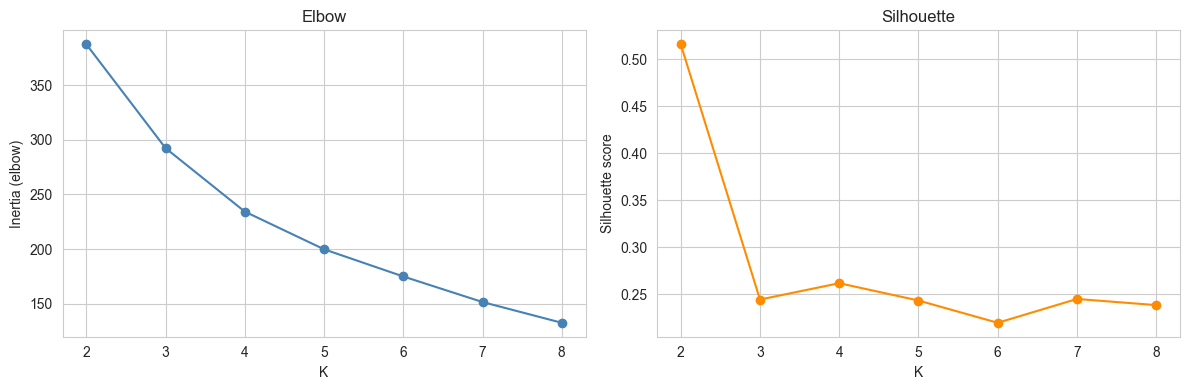


K óptimo por silhouette: 2

Distribución de clusters en el dataset:
cluster_arquetipo
0     2111
1    61054

Test uplift cluster_arquetipo en LightGBM default
  CV RMSE sin cluster: 0.3153
  CV RMSE con cluster: 0.3146
  Uplift (positivo = mejora): +0.0007

Decisión: NO incluir cluster_arquetipo en modelos finales


In [26]:
## =============================================================================
## FASE 6.5 - CLUSTERING EXPERIMENTAL (arquetipo institucional)
## =============================================================================
## Objetivo: capturar grupos de instituciones similares y agregar cluster_id
## como feature adicional al modelo ganador. Si no mejora, lo dejamos
## documentado como "experimento sin uplift".

## --- Features estructurales agregadas por institución (agnóstico al año) ---
struct_features = [
    "N°Docentes", "pct_doctores", "pct_magister", "pct_especialistas",
    "pct_horas_jornada_completa",
    "valor_arancel", "valor_matricula",
    "puntaje_corte_ultimo",
    "densidad_estudiantes_m2",
]

inst_profile = (
    df_train.groupby("NOMBRE INSTITUCIÓN")[struct_features]
    .mean()
    .reset_index()
)
print(f"Perfil estructural: {inst_profile.shape[0]} instituciones x {len(struct_features)} features")

## --- Determinar K óptimo (elbow + silhouette) ---
from sklearn.metrics import silhouette_score

X_struct = StandardScaler().fit_transform(inst_profile[struct_features])

ks = range(2, 9)
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_struct)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_struct, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(ks), inertias, "o-", color="steelblue")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia (elbow)")
axes[0].set_title("Elbow")
axes[1].plot(list(ks), silhouettes, "o-", color="darkorange")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette")
plt.tight_layout(); plt.show()

K_OPT = list(ks)[int(np.argmax(silhouettes))]
print(f"\nK óptimo por silhouette: {K_OPT}")

## --- Asignar cluster_id al dataset completo ---
km_final = KMeans(n_clusters=K_OPT, random_state=SEED, n_init=10)
inst_profile["cluster_arquetipo"] = km_final.fit_predict(X_struct).astype(str)

cluster_map = dict(zip(inst_profile["NOMBRE INSTITUCIÓN"], inst_profile["cluster_arquetipo"]))
df["cluster_arquetipo"] = df["NOMBRE INSTITUCIÓN"].map(cluster_map).fillna("desconocido")
df_train["cluster_arquetipo"] = df_train["NOMBRE INSTITUCIÓN"].map(cluster_map).fillna("desconocido")
df_test["cluster_arquetipo"] = df_test["NOMBRE INSTITUCIÓN"].map(cluster_map).fillna("desconocido")

print(f"\nDistribución de clusters en el dataset:")
print(df["cluster_arquetipo"].value_counts().sort_index().to_string())

## --- Test del uplift: LightGBM default con vs sin cluster_id ---
print_section("Test uplift cluster_arquetipo en LightGBM default")

features_with_cluster = features_set_a + ["cluster_arquetipo"]
cat_with_cluster = CAT_FOR_TE + ["cluster_arquetipo"]
num_with_cluster = [c for c in features_with_cluster if c not in cat_with_cluster]

lgbm_with_cluster = Pipeline([
    ("pre", build_preprocessor(num_with_cluster, cat_with_cluster)),
    ("model", lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.05, num_leaves=31,
        random_state=SEED, n_jobs=-1, verbose=-1,
    )),
])

X_train_cl = df_train[features_with_cluster].copy()
res_with = cv_evaluate(lgbm_with_cluster, X_train_cl, y_train, df_train, sample_weight=sw_train, verbose=False)
print(f"  CV RMSE sin cluster: {results_models['LGBM_default']['RMSE_mean']:.4f}")
print(f"  CV RMSE con cluster: {res_with['summary']['RMSE_mean']:.4f}")
uplift = results_models["LGBM_default"]["RMSE_mean"] - res_with["summary"]["RMSE_mean"]
print(f"  Uplift (positivo = mejora): {uplift:+.4f}")

INCLUIR_CLUSTER = uplift > 0.001
print(f"\nDecisión: {'INCLUIR' if INCLUIR_CLUSTER else 'NO incluir'} cluster_arquetipo en modelos finales")

if INCLUIR_CLUSTER:
    features_set_a = features_with_cluster
    CAT_FOR_TE_FINAL = cat_with_cluster
    num_set_a = num_with_cluster
else:
    CAT_FOR_TE_FINAL = CAT_FOR_TE

In [27]:
## =============================================================================
## FASE 7.1 - HYPERPARAMETER TUNING: LightGBM con Optuna
## =============================================================================
## 100 trials, MedianPruner con startup=10 y warmup=2 folds.
## Objetivo: RMSE promedio en CV temporal expanding window.

N_TRIALS = 50

X_train_full = df_train[features_set_a].copy()

def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 2000, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "random_state": SEED,
        "n_jobs": -1,
        "verbose": -1,
    }

    folds = temporal_cv_split(df_train, year_col=YEAR_COL)
    fold_rmses = []
    for i, (tr_idx, va_idx, _, _) in enumerate(folds):
        pipe = Pipeline([
            ("pre", build_preprocessor(num_set_a, CAT_FOR_TE_FINAL)),
            ("model", lgb.LGBMRegressor(**params)),
        ])
        fit_kwargs = {}
        if sw_train is not None:
            pos_tr = df_train.index.get_indexer(tr_idx)
            fit_kwargs["model__sample_weight"] = sw_train[pos_tr]
        pipe.fit(X_train_full.loc[tr_idx], y_train.loc[tr_idx], **fit_kwargs)
        pred = pipe.predict(X_train_full.loc[va_idx])
        rmse = float(np.sqrt(mean_squared_error(y_train.loc[va_idx], pred)))
        fold_rmses.append(rmse)
        trial.report(np.mean(fold_rmses), step=i)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    return float(np.mean(fold_rmses))

sampler = TPESampler(seed=SEED)
pruner = MedianPruner(n_startup_trials=10, n_warmup_steps=2)
study_lgbm = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner,
                                 study_name="lgbm_admision")

start = datetime.now()
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS, show_progress_bar=False)
elapsed = (datetime.now() - start).total_seconds()

print(f"LightGBM Optuna terminado en {elapsed/60:.1f} min ({len(study_lgbm.trials)} trials)")
print(f"Mejor RMSE CV: {study_lgbm.best_value:.4f}")
print(f"Mejores params:")
for k, v in study_lgbm.best_params.items():
    print(f"  {k}: {v}")

LightGBM Optuna terminado en 25.5 min (50 trials)
Mejor RMSE CV: 0.3122
Mejores params:
  n_estimators: 1900
  learning_rate: 0.009885054520661091
  num_leaves: 195
  max_depth: 11
  min_child_samples: 66
  subsample: 0.971043064661989
  colsample_bytree: 0.6177422642317241
  reg_alpha: 0.011354663430228777
  reg_lambda: 0.0015564756824235568


In [28]:
## =============================================================================
## FASE 7.2 - HYPERPARAMETER TUNING: XGBoost con Optuna
## =============================================================================

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 2000, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 20),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "random_state": SEED,
        "n_jobs": -1,
        "verbosity": 0,
        "tree_method": "hist",
    }

    folds = temporal_cv_split(df_train, year_col=YEAR_COL)
    fold_rmses = []
    for i, (tr_idx, va_idx, _, _) in enumerate(folds):
        pipe = Pipeline([
            ("pre", build_preprocessor(num_set_a, CAT_FOR_TE_FINAL)),
            ("model", xgb.XGBRegressor(**params)),
        ])
        fit_kwargs = {}
        if sw_train is not None:
            pos_tr = df_train.index.get_indexer(tr_idx)
            fit_kwargs["model__sample_weight"] = sw_train[pos_tr]
        pipe.fit(X_train_full.loc[tr_idx], y_train.loc[tr_idx], **fit_kwargs)
        pred = pipe.predict(X_train_full.loc[va_idx])
        rmse = float(np.sqrt(mean_squared_error(y_train.loc[va_idx], pred)))
        fold_rmses.append(rmse)
        trial.report(np.mean(fold_rmses), step=i)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    return float(np.mean(fold_rmses))

study_xgb = optuna.create_study(direction="minimize", sampler=TPESampler(seed=SEED),
                                pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=2),
                                study_name="xgb_admision")

start = datetime.now()
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=False)
elapsed = (datetime.now() - start).total_seconds()

print(f"XGBoost Optuna terminado en {elapsed/60:.1f} min ({len(study_xgb.trials)} trials)")
print(f"Mejor RMSE CV: {study_xgb.best_value:.4f}")
print(f"Mejores params:")
for k, v in study_xgb.best_params.items():
    print(f"  {k}: {v}")

XGBoost Optuna terminado en 11.4 min (50 trials)
Mejor RMSE CV: 0.3140
Mejores params:
  n_estimators: 1900
  learning_rate: 0.027651749844253826
  max_depth: 6
  min_child_weight: 1.0908281541971867
  subsample: 0.8190693147055654
  colsample_bytree: 0.7671943211321459
  reg_alpha: 0.006624241197703069
  reg_lambda: 0.9431762304922121
  gamma: 0.1836535010870898


In [29]:
## =============================================================================
## FASE 7.3 - HYPERPARAMETER TUNING: CatBoost con Optuna
## =============================================================================

def objective_cat(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 2000, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-2, 30.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_state": SEED,
        "verbose": 0,
    }

    folds = temporal_cv_split(df_train, year_col=YEAR_COL)
    fold_rmses = []
    for i, (tr_idx, va_idx, _, _) in enumerate(folds):
        pipe = Pipeline([
            ("pre", build_preprocessor(num_set_a, CAT_FOR_TE_FINAL)),
            ("model", cb.CatBoostRegressor(**params)),
        ])
        fit_kwargs = {}
        if sw_train is not None:
            pos_tr = df_train.index.get_indexer(tr_idx)
            fit_kwargs["model__sample_weight"] = sw_train[pos_tr]
        pipe.fit(X_train_full.loc[tr_idx], y_train.loc[tr_idx], **fit_kwargs)
        pred = pipe.predict(X_train_full.loc[va_idx])
        rmse = float(np.sqrt(mean_squared_error(y_train.loc[va_idx], pred)))
        fold_rmses.append(rmse)
        trial.report(np.mean(fold_rmses), step=i)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    return float(np.mean(fold_rmses))

study_cat = optuna.create_study(direction="minimize", sampler=TPESampler(seed=SEED),
                                pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=2),
                                study_name="cat_admision")

start = datetime.now()
study_cat.optimize(objective_cat, n_trials=N_TRIALS, show_progress_bar=False)
elapsed = (datetime.now() - start).total_seconds()

print(f"CatBoost Optuna terminado en {elapsed/60:.1f} min ({len(study_cat.trials)} trials)")
print(f"Mejor RMSE CV: {study_cat.best_value:.4f}")
print(f"Mejores params:")
for k, v in study_cat.best_params.items():
    print(f"  {k}: {v}")

CatBoost Optuna terminado en 78.7 min (50 trials)
Mejor RMSE CV: 0.3109
Mejores params:
  iterations: 1600
  learning_rate: 0.022704419548304083
  depth: 8
  l2_leaf_reg: 1.5877486946725636
  bagging_temperature: 0.20162951947030372
  border_count: 132


In [30]:
## =============================================================================
## FASE 7.4 - COMPARACIÓN DE MODELOS TUNEADOS Y SELECCIÓN DEL GANADOR
## =============================================================================

resumen_tuning = pd.DataFrame({
    "Modelo": ["LightGBM_tuned", "XGBoost_tuned", "CatBoost_tuned"],
    "RMSE_CV": [study_lgbm.best_value, study_xgb.best_value, study_cat.best_value],
    "N_trials_completados": [
        len([t for t in study_lgbm.trials if t.state.name == "COMPLETE"]),
        len([t for t in study_xgb.trials if t.state.name == "COMPLETE"]),
        len([t for t in study_cat.trials if t.state.name == "COMPLETE"]),
    ],
}).sort_values("RMSE_CV").reset_index(drop=True)

print("Ranking modelos tuneados (CV temporal):")
print(resumen_tuning.round(4).to_string())

GANADOR = resumen_tuning.iloc[0]["Modelo"]
print(f"\nModelo ganador: {GANADOR}")

best_params_map = {
    "LightGBM_tuned": study_lgbm.best_params,
    "XGBoost_tuned": study_xgb.best_params,
    "CatBoost_tuned": study_cat.best_params,
}

best_params = best_params_map[GANADOR]

def make_model(model_name, params):
    p = {**params}
    if model_name == "LightGBM_tuned":
        p.update({"random_state": SEED, "n_jobs": -1, "verbose": -1})
        return lgb.LGBMRegressor(**p)
    if model_name == "XGBoost_tuned":
        p.update({"random_state": SEED, "n_jobs": -1, "verbosity": 0, "tree_method": "hist"})
        return xgb.XGBRegressor(**p)
    if model_name == "CatBoost_tuned":
        p.update({"random_state": SEED, "verbose": 0})
        return cb.CatBoostRegressor(**p)
    raise ValueError(model_name)

def make_pipeline_final():
    return Pipeline([
        ("pre", build_preprocessor(num_set_a, CAT_FOR_TE_FINAL)),
        ("model", make_model(GANADOR, best_params)),
    ])

Ranking modelos tuneados (CV temporal):
           Modelo  RMSE_CV  N_trials_completados
0  CatBoost_tuned   0.3109                    49
1  LightGBM_tuned   0.3122                    50
2   XGBoost_tuned   0.3140                    50

Modelo ganador: CatBoost_tuned



CatBoost_tuned en holdout 2025
Escala arcsinh:
  test_arcsinh_RMSE: 0.2897
  test_arcsinh_MAE: 0.2051
  test_arcsinh_MedAE: 0.1352
  test_arcsinh_R2: 0.1755

Escala original (tasa real):
  test_orig_RMSE: 0.3139
  test_orig_MAE: 0.2160
  test_orig_MedAE: 0.1369
  test_orig_R2: 0.1788

Error medio absoluto por región (test 2025)
REGIÓN
Atacama                   0.2402
Aysén                     0.2391
Valparaíso                0.2366
Magallanes                0.2332
Lib. Gral. B. O'Higgins   0.2311
Metropolitana             0.2306
Los Lagos                 0.2128
Tarapacá                  0.2123
Arica y Parinacota        0.2109
Ñuble                     0.2108
Biobío                    0.2100
Antofagasta               0.2051
La Araucanía              0.1984
Coquimbo                  0.1711
Los Ríos                  0.1704
Maule                     0.1640


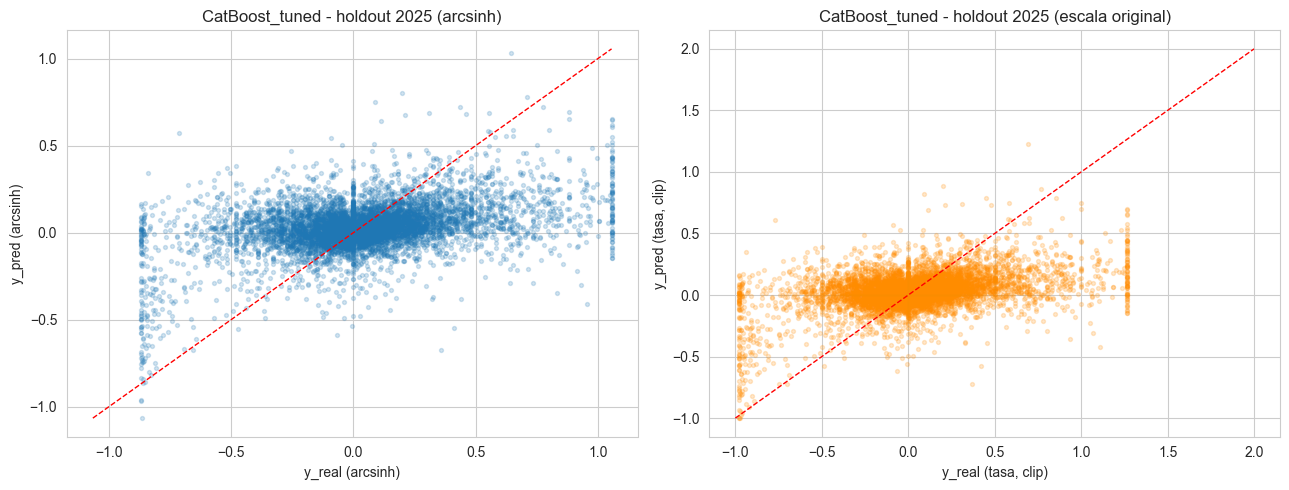

In [31]:
## =============================================================================
## FASE 8.1 - REFIT DEL GANADOR EN TRAIN (2019-2024) Y EVALUACIÓN EN HOLDOUT 2025
## =============================================================================

pipe_winner = make_pipeline_final()
fit_kwargs_winner = {}
if sw_train is not None:
    fit_kwargs_winner["model__sample_weight"] = sw_train
pipe_winner.fit(X_train_full, y_train, **fit_kwargs_winner)

X_test_full = df_test[features_set_a].copy()
y_pred_test = pipe_winner.predict(X_test_full)

metrics_test_arcsinh = compute_metrics(y_test, y_pred_test, prefix="test_arcsinh_")
metrics_test_orig = compute_metrics(np.sinh(y_test), np.sinh(y_pred_test), prefix="test_orig_")

print_section(f"{GANADOR} en holdout 2025")
print("Escala arcsinh:")
for k, v in metrics_test_arcsinh.items():
    print(f"  {k}: {v:.4f}")
print("\nEscala original (tasa real):")
for k, v in metrics_test_orig.items():
    print(f"  {k}: {v:.4f}")

## --- Métricas por subgrupo ---
df_test_eval = df_test.copy()
df_test_eval["y_pred"] = y_pred_test
df_test_eval["y_pred_real"] = np.sinh(y_pred_test)
df_test_eval["y_real_real"] = np.sinh(y_test.values)
df_test_eval["residuo"] = df_test_eval["y_real_real"] - df_test_eval["y_pred_real"]
df_test_eval["residuo_abs"] = df_test_eval["residuo"].abs()

print_section("Error medio absoluto por región (test 2025)")
print(df_test_eval.groupby("REGIÓN")["residuo_abs"].mean().sort_values(ascending=False).round(4).to_string())

## --- Visualización: scatter pred vs real ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.2, s=8)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel("y_real (arcsinh)"); axes[0].set_ylabel("y_pred (arcsinh)")
axes[0].set_title(f"{GANADOR} - holdout 2025 (arcsinh)")

axes[1].scatter(np.sinh(y_test).clip(-1, 2), np.sinh(y_pred_test).clip(-1, 2), alpha=0.2, s=8, color="darkorange")
axes[1].plot([-1, 2], [-1, 2], "r--", linewidth=1)
axes[1].set_xlabel("y_real (tasa, clip)"); axes[1].set_ylabel("y_pred (tasa, clip)")
axes[1].set_title(f"{GANADOR} - holdout 2025 (escala original)")

plt.tight_layout()
plt.show()

In [32]:
## =============================================================================
## FASE 8.2 - EXPERIMENTO: TE-LEAKY vs TE-FOLD-AWARE
## =============================================================================
## Cuantifica el impacto del riesgo de leakage detectado al inicio del proyecto.
## Entrenamos el modelo ganador con (a) las columnas te_* pre-calculadas
## (leaky) y (b) TargetEncoder fold-aware. Reportamos la diferencia.

te_cols_precalc = [c for c in df.columns if c.startswith("te_")]
print(f"Columnas te_* pre-calculadas: {te_cols_precalc}")

if len(te_cols_precalc) > 0:
    ## Set leaky: reemplaza las categóricas originales por sus te_* pre-calculadas.
    ## Si cluster está incluido, se mantiene con TE fold-aware en ambos sets para
    ## que la comparación aísle ÚNICAMENTE el efecto del TE leaky.
    cat_no_cluster = [c for c in CAT_FOR_TE_FINAL if c != "cluster_arquetipo"]
    cat_solo_cluster = ["cluster_arquetipo"] if "cluster_arquetipo" in CAT_FOR_TE_FINAL else []

    features_leaky = (
        [c for c in features_set_a if c not in CAT_FOR_TE_FINAL]  ## todo lo no-categórico
        + te_cols_precalc                                          ## + te_* leaky
        + cat_solo_cluster                                         ## + cluster (fold-aware)
    )
    num_leaky = [c for c in features_leaky if c not in cat_solo_cluster]

    transformers_leaky = [("num", "passthrough", num_leaky)]
    if cat_solo_cluster:
        transformers_leaky.append(("te_cluster", TargetEncoder(smoothing=30.0), cat_solo_cluster))

    pipe_leaky = Pipeline([
        ("pre", ColumnTransformer(transformers_leaky, remainder="drop")),
        ("model", make_model(GANADOR, best_params)),
    ])

    X_train_leaky = df_train[features_leaky].copy()
    res_leaky = cv_evaluate(pipe_leaky, X_train_leaky, y_train, df_train,
                             sample_weight=sw_train, verbose=False)

    rmse_correcto = study_lgbm.best_value if GANADOR == "LightGBM_tuned" else (
        study_xgb.best_value if GANADOR == "XGBoost_tuned" else study_cat.best_value
    )

    print_section("TE-leaky vs TE-fold-aware (CV RMSE)")
    print(f"  TE-leaky (te_* pre-calc):     RMSE = {res_leaky['summary']['RMSE_mean']:.4f}")
    print(f"  TE-fold-aware (correcto):     RMSE = {rmse_correcto:.4f}")
    delta = res_leaky['summary']['RMSE_mean'] - rmse_correcto
    print(f"  Delta (leaky - correcto):     {delta:+.4f}")
    if delta < 0:
        print(f"  -> El leaky reportó MEJOR RMSE (optimismo sesgado: {abs(delta):.4f} puntos).")
        print(f"  -> Confiar en el TE pre-calculado habría inflado el desempeño en {abs(delta)/rmse_correcto*100:.1f}%.")
    else:
        print(f"  -> El leaky reportó PEOR RMSE (caso inusual; revisar smoothing o cardinalidad).")
else:
    print("No hay columnas te_* en el dataset - experimento omitido.")

Columnas te_* pre-calculadas: ['te_REGIÓN', 'te_NOMBRE INSTITUCIÓN', 'te_NOMBRE CARRERA', 'te_area_conocimiento']

TE-leaky vs TE-fold-aware (CV RMSE)
  TE-leaky (te_* pre-calc):     RMSE = 0.3047
  TE-fold-aware (correcto):     RMSE = 0.3109
  Delta (leaky - correcto):     -0.0062
  -> El leaky reportó MEJOR RMSE (optimismo sesgado: 0.0062 puntos).
  -> Confiar en el TE pre-calculado habría inflado el desempeño en 2.0%.


Shape matriz transformada: (55413, 46)
N° features: 46


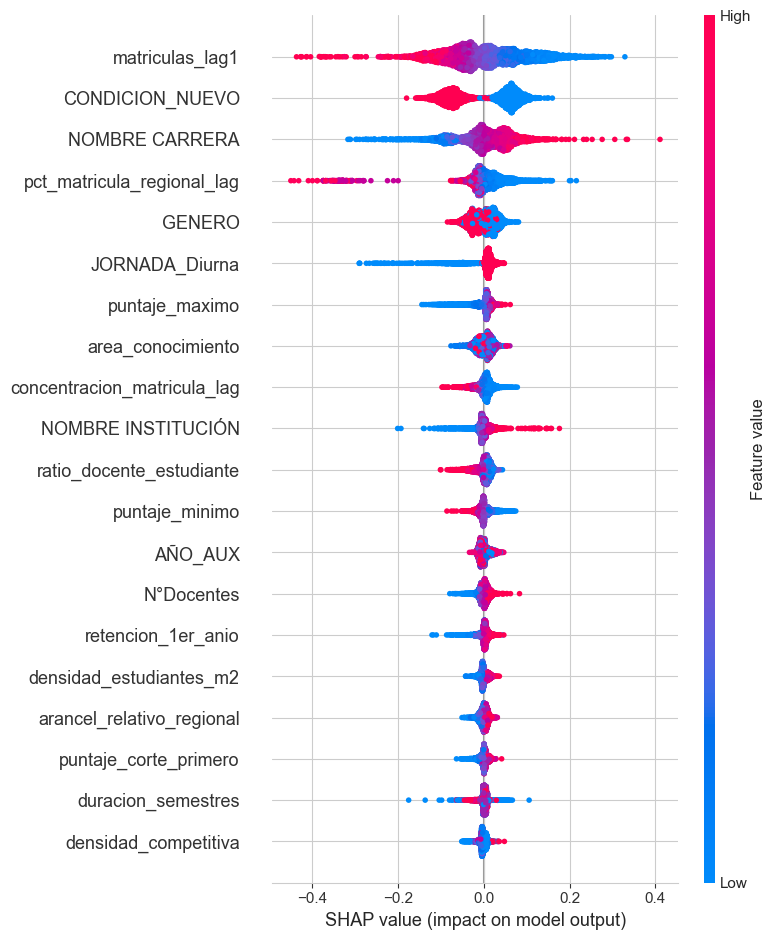

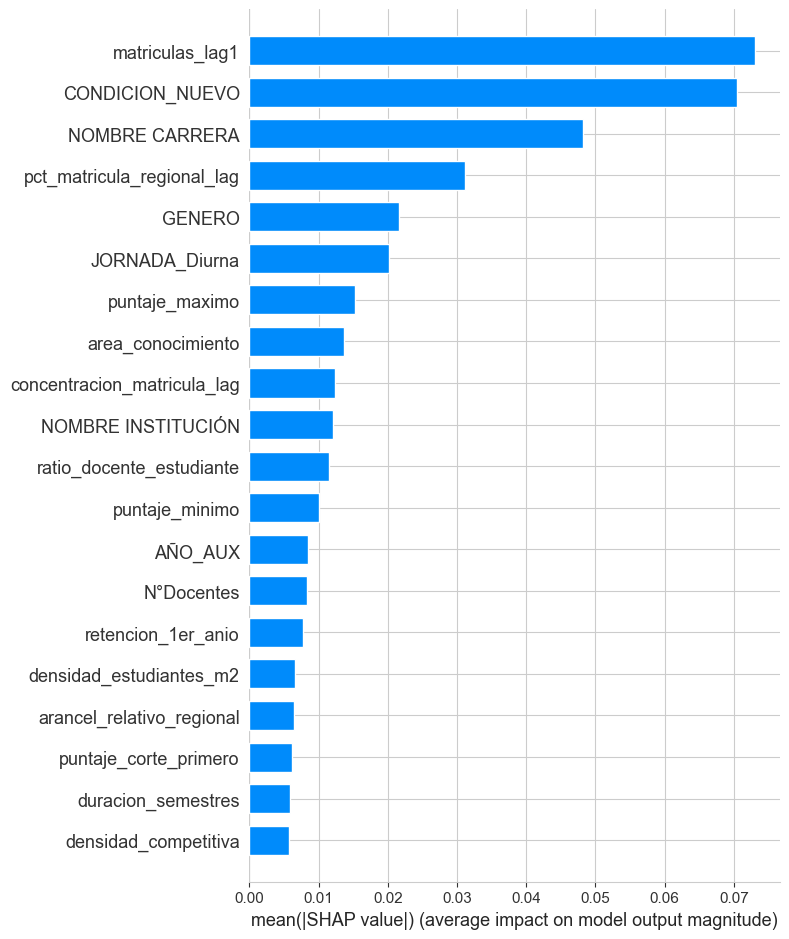


Top 15 features por importancia SHAP:
                        feature  shap_mean_abs
0               matriculas_lag1         0.0730
1               CONDICION_NUEVO         0.0705
2                NOMBRE CARRERA         0.0482
3    pct_matricula_regional_lag         0.0311
4                        GENERO         0.0217
5                JORNADA_Diurna         0.0202
6                puntaje_maximo         0.0152
7             area_conocimiento         0.0136
8   concentracion_matricula_lag         0.0123
9            NOMBRE INSTITUCIÓN         0.0121
10     ratio_docente_estudiante         0.0116
11               puntaje_minimo         0.0101
12                      AÑO_AUX         0.0084
13                   N°Docentes         0.0083
14           retencion_1er_anio         0.0077

Top 5 features para SHAP por fila en export: ['matriculas_lag1', 'CONDICION_NUEVO', 'NOMBRE CARRERA', 'pct_matricula_regional_lag', 'GENERO']


In [33]:
## =============================================================================
## FASE 9 - INTERPRETABILIDAD CON SHAP
## =============================================================================

## --- Aplicar preprocesador a X_train para obtener matriz numérica para SHAP ---
preprocessor_fitted = pipe_winner.named_steps["pre"]
model_fitted = pipe_winner.named_steps["model"]

X_train_transformed = preprocessor_fitted.transform(X_train_full)
feature_names_out = []
for name, _, cols in preprocessor_fitted.transformers_:
    if name == "remainder":
        continue
    feature_names_out.extend(cols if isinstance(cols, list) else [cols])

print(f"Shape matriz transformada: {X_train_transformed.shape}")
print(f"N° features: {len(feature_names_out)}")

## --- TreeExplainer (rápido para LGBM/XGB/CatBoost) ---
explainer = shap.TreeExplainer(model_fitted)
## Sample para velocidad
n_sample = min(5000, len(X_train_transformed))
sample_idx = np.random.RandomState(SEED).choice(len(X_train_transformed), n_sample, replace=False)
X_sample = X_train_transformed[sample_idx] if hasattr(X_train_transformed, "__getitem__") else X_train_transformed.iloc[sample_idx]

shap_values = explainer.shap_values(X_sample)

## --- Summary plot global ---
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names_out,
                  plot_type="dot", show=False, max_display=20)
plt.tight_layout()
plt.show()

## --- Bar plot global (importancia agregada) ---
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names_out,
                  plot_type="bar", show=False, max_display=20)
plt.tight_layout()
plt.show()

## --- Top features ordenadas por importancia SHAP ---
shap_importance = pd.DataFrame({
    "feature": feature_names_out,
    "shap_mean_abs": np.abs(shap_values).mean(axis=0),
}).sort_values("shap_mean_abs", ascending=False).reset_index(drop=True)

print("\nTop 15 features por importancia SHAP:")
print(shap_importance.head(15).to_string())

TOP_FEATURES_SHAP = shap_importance.head(5)["feature"].tolist()
print(f"\nTop 5 features para SHAP por fila en export: {TOP_FEATURES_SHAP}")

In [34]:
## =============================================================================
## FASE 10 - REFIT FINAL CON TODO EL HISTÓRICO (2019-2025)
## =============================================================================
## Para el forecast 2026 necesitamos el modelo entrenado con TODOS los años
## disponibles. Para el retrospectivo OOF usamos el código de la fase 11.

X_all = df[features_set_a].copy()
y_all = df[TARGET].copy()

pipe_final = make_pipeline_final()
fit_kwargs_final = {}
if sw_all is not None:
    fit_kwargs_final["model__sample_weight"] = sw_all
pipe_final.fit(X_all, y_all, **fit_kwargs_final)

print(f"Modelo final ({GANADOR}) entrenado con {len(X_all):,} filas.")
print(f"Hyperparams usados: {best_params}")
if sw_all is not None:
    n_covid = (sw_all != 1.0).sum()
    print(f"Sample weights: {n_covid:,} filas COVID con peso {COVID_HANDLING['covid_weight']}")

Modelo final (CatBoost_tuned) entrenado con 63,165 filas.
Hyperparams usados: {'iterations': 1600, 'learning_rate': 0.022704419548304083, 'depth': 8, 'l2_leaf_reg': 1.5877486946725636, 'bagging_temperature': 0.20162951947030372, 'border_count': 132}


In [35]:
## =============================================================================
## FASE 11.1 - PREDICCIONES OOF RETROSPECTIVAS
## =============================================================================
## Para cada año Y entre {2019, 2020, ..., 2025}:
##     Entrenar con datos < Y
##     Predecir Y (predicción out-of-fold; cada fila se predice sin que el modelo
##     haya visto su año)
## 2018 NO tiene predicción OOF (no hay año previo en el dataset; solo se usa
## como base del lag).

oof_pred_dict = {}
years_oof = sorted(df[YEAR_COL].unique())[1:]  ## 2019-2025 (excluye 2018)

for y_target in years_oof:
    mask_tr = df[YEAR_COL] < y_target
    mask_va = df[YEAR_COL] == y_target

    X_tr = df.loc[mask_tr, features_set_a].copy()
    y_tr = df.loc[mask_tr, TARGET].copy()
    X_va = df.loc[mask_va, features_set_a].copy()

    ## Construir sample_weight para el subset de train de este año
    fit_kwargs_oof = {}
    if sw_all is not None:
        sw_tr_year = sw_all[df.index.get_indexer(df.loc[mask_tr].index)]
        fit_kwargs_oof["model__sample_weight"] = sw_tr_year

    pipe = make_pipeline_final()
    pipe.fit(X_tr, y_tr, **fit_kwargs_oof)
    pred = pipe.predict(X_va)
    oof_pred_dict[y_target] = pd.Series(pred, index=df.loc[mask_va].index)
    print(f"  OOF predicción para {y_target}: train_n={mask_tr.sum():,}, val_n={mask_va.sum():,}")

## --- Construir serie OOF completa ---
oof_series = pd.concat(oof_pred_dict.values()).sort_index()
df["pred_arcsinh_oof"] = np.nan
df.loc[oof_series.index, "pred_arcsinh_oof"] = oof_series.values

print(f"\nFilas con predicción OOF: {df['pred_arcsinh_oof'].notna().sum():,}")
print(f"Filas sin OOF (año 2018, base de lag): {df['pred_arcsinh_oof'].isna().sum():,}")

  OOF predicción para 2019: train_n=8,444, val_n=8,264
  OOF predicción para 2020: train_n=16,708, val_n=7,967
  OOF predicción para 2021: train_n=24,675, val_n=7,652
  OOF predicción para 2022: train_n=32,327, val_n=7,595
  OOF predicción para 2023: train_n=39,922, val_n=7,607
  OOF predicción para 2024: train_n=47,529, val_n=7,884
  OOF predicción para 2025: train_n=55,413, val_n=7,752

Filas con predicción OOF: 54,721
Filas sin OOF (año 2018, base de lag): 8,444


In [36]:
## =============================================================================
## FASE 11.2 - CONSTRUCCIÓN DE FEATURES 2026 Y FORECAST
## =============================================================================
## Estrategia: tomamos las filas de 2025, las clonamos a 2026 y ajustamos:
##   - matriculas_lag1   <- log1p(matriculas_real_2025)
##   - concentracion_matricula_lag, pct_matricula_regional_lag <- recalculadas con 2025
##   - Resto de features exógenas (PIB, desempleo, aranceles, docentes, etc.):
##     asumidas iguales a 2025 (supuesto conservador)

df_2025 = df[df[YEAR_COL] == 2025].copy()
df_2026 = df_2025.copy()
df_2026[YEAR_COL] = 2026

## --- 1) Actualizar matriculas_lag1 con matrículas reales 2025 ---
df_2026["matriculas_lag1"] = np.log1p(df_2025["matriculas_real_recon"].values)

## --- 2) Recalcular concentracion_matricula_lag y pct_matricula_regional_lag ---
##     concentracion_matricula_lag_2026 = matriculas_2025 / total_inst_2025
##     pct_matricula_regional_lag_2026  = matriculas_2025 / total_carrera_region_2025
total_por_inst = df_2025.groupby("NOMBRE INSTITUCIÓN")["matriculas_real_recon"].sum()
total_carrera_region = df_2025.groupby(["NOMBRE CARRERA", "REGIÓN"])["matriculas_real_recon"].sum().reset_index()
total_carrera_region.columns = ["NOMBRE CARRERA", "REGIÓN", "total_cr"]

## concentracion_matricula_lag
df_2026["concentracion_matricula_lag"] = (
    df_2025["matriculas_real_recon"].values
    / df_2025["NOMBRE INSTITUCIÓN"].map(total_por_inst).replace(0, np.nan).values
)
df_2026["concentracion_matricula_lag"] = df_2026["concentracion_matricula_lag"].fillna(0).clip(0, 1)

## pct_matricula_regional_lag (usando merge para mayor seguridad)
df_2025_merge = df_2025[["NOMBRE CARRERA", "REGIÓN", "matriculas_real_recon"]].reset_index().merge(
    total_carrera_region, on=["NOMBRE CARRERA", "REGIÓN"], how="left"
).set_index("index")
df_2026["pct_matricula_regional_lag"] = (
    df_2025_merge["matriculas_real_recon"]
    / df_2025_merge["total_cr"].replace(0, np.nan)
).fillna(0).clip(0, 1).values

## --- 3) densidad_competitiva permanece igual (el universo de carrera-región no cambia) ---
##     PIB, desempleo, aranceles, docentes, inmuebles: se mantienen iguales a 2025

## --- 4) Predecir 2026 con el modelo final ---
X_2026 = df_2026[features_set_a].copy()
pred_2026 = pipe_final.predict(X_2026)
df_2026["pred_arcsinh_oof"] = pred_2026
df_2026["tasa_crecimiento"] = np.nan  ## no existe target real para 2026
df_2026["matriculas_real_recon"] = np.nan  ## se calculará al reconstruir

## --- 5) Reconstruir matrículas predichas 2026 ---
matriculas_lag_2026 = np.expm1(df_2026["matriculas_lag1"].values)
tasa_pred_2026 = np.sinh(pred_2026)
df_2026["matriculas_pred"] = matriculas_lag_2026 * (1.0 + tasa_pred_2026)

print(f"Forecast 2026 generado: {len(df_2026):,} filas")
print(f"  Suma matrículas predichas 2026: {df_2026['matriculas_pred'].sum():,.0f}")
print(f"  Suma matrículas reales 2025:    {df_2025['matriculas_real_recon'].sum():,.0f}")
crec_total = (df_2026['matriculas_pred'].sum() - df_2025['matriculas_real_recon'].sum()) / df_2025['matriculas_real_recon'].sum() * 100
print(f"  Crecimiento total agregado:     {crec_total:+.2f}%")

Forecast 2026 generado: 7,752 filas
  Suma matrículas predichas 2026: 612,578
  Suma matrículas reales 2025:    597,050
  Crecimiento total agregado:     +2.60%


In [37]:
## =============================================================================
## FASE 11.3 - CONSTRUCCIÓN DEL DATAFRAME DE EXPORT
## =============================================================================
## Granularidad: institución x carrera x región x jornada x género x condición x año
## Filas: 2019-2025 (retrospectivo) + 2026 (forecast)

## --- Reconstruir JORNADA y CONDICION desde columnas OHE ---
## Detectamos dinámicamente la jornada base (referencia drop_first)
JORNADAS_POSIBLES = ["Diurna", "Vespertina", "Semipresencial", "Otra"]
jornadas_ohe_presentes = [c.replace("JORNADA_", "") for c in df.columns if c.startswith("JORNADA_")]
jornada_base_candidatas = [j for j in JORNADAS_POSIBLES if j not in jornadas_ohe_presentes]
JORNADA_BASE = jornada_base_candidatas[0] if jornada_base_candidatas else "Diurna"
print(f"Jornadas en OHE: {jornadas_ohe_presentes}")
print(f"Jornada base (cuando todas las dummies = 0): {JORNADA_BASE}")

def reconstruct_jornada(row):
    for j in jornadas_ohe_presentes:
        if row.get(f"JORNADA_{j}", 0) == 1:
            return j
    return JORNADA_BASE

def reconstruct_genero(g):
    return {0: "MUJER", 1: "HOMBRE", 2: "NO_BINARIO"}.get(g, "DESCONOCIDO")

def reconstruct_condicion(row):
    return "NUEVO" if row.get("CONDICION_NUEVO", 0) == 1 else "ANTIGUO"

def build_export_row(df_input, tipo):
    out = pd.DataFrame()
    out["anio"] = df_input[YEAR_COL].astype(np.int16)
    out["region"] = df_input["REGIÓN"].astype("category")
    out["institucion"] = df_input["NOMBRE INSTITUCIÓN"].astype("category")
    out["carrera"] = df_input["NOMBRE CARRERA"].astype("category")
    out["area_conocimiento"] = df_input["area_conocimiento"].astype("category")
    out["jornada"] = df_input.apply(reconstruct_jornada, axis=1).astype("category")
    out["genero"] = df_input["GENERO"].apply(reconstruct_genero).astype("category")
    out["condicion"] = df_input.apply(reconstruct_condicion, axis=1).astype("category")
    out["tipo_registro"] = tipo
    return out

## --- Retrospectivo (2019-2025) ---
exp_retro = build_export_row(df, tipo="retrospectivo")
exp_retro["matriculas_lag"] = np.expm1(df["matriculas_lag1"]).round().astype(np.int32)
exp_retro["matriculas_real"] = df["matriculas_real_recon"].round().astype("Int32")
exp_retro["tasa_pred_arcsinh"] = df["pred_arcsinh_oof"].astype(np.float32)
exp_retro["tasa_pred"] = np.sinh(df["pred_arcsinh_oof"]).astype(np.float32)
exp_retro["tasa_real"] = np.sinh(df["tasa_crecimiento"]).astype(np.float32)
exp_retro["matriculas_pred"] = (
    exp_retro["matriculas_lag"].astype(float) * (1.0 + exp_retro["tasa_pred"].astype(float))
).astype(np.float32)

## Marcar año 2018 sin predicción (no hay OOF posible: no existe año previo en el dataset).
## Las predicciones OOF arrancan en 2019 (entrenado con 2018).
mask_sin_pred = exp_retro["anio"] == 2018
exp_retro.loc[mask_sin_pred, ["tasa_pred", "tasa_pred_arcsinh", "matriculas_pred"]] = np.nan
exp_retro.loc[mask_sin_pred, "tipo_registro"] = "historico_sin_pred"

## --- Forecast 2026 ---
exp_fc = build_export_row(df_2026, tipo="forecast")
exp_fc["matriculas_lag"] = np.expm1(df_2026["matriculas_lag1"]).round().astype(np.int32)
exp_fc["matriculas_real"] = pd.array([pd.NA] * len(df_2026), dtype="Int32")
exp_fc["tasa_pred_arcsinh"] = df_2026["pred_arcsinh_oof"].astype(np.float32).values
exp_fc["tasa_pred"] = np.sinh(df_2026["pred_arcsinh_oof"]).astype(np.float32).values
exp_fc["tasa_real"] = np.nan
exp_fc["matriculas_pred"] = df_2026["matriculas_pred"].astype(np.float32).values

## --- Combinar ---
export_df = pd.concat([exp_retro, exp_fc], ignore_index=True)

## --- Métricas de error (solo retrospectivos con predicción válida) ---
export_df["residuo_tasa"] = export_df["tasa_real"] - export_df["tasa_pred"]
export_df["residuo_matriculas"] = export_df["matriculas_real"].astype(float) - export_df["matriculas_pred"].astype(float)
mask_for_pct = (export_df["matriculas_real"].notna()) & (export_df["matriculas_real"] > 0)
export_df["error_absoluto_pct"] = np.where(
    mask_for_pct,
    export_df["residuo_matriculas"].abs() / export_df["matriculas_real"].astype(float),
    np.nan,
).astype(np.float32)

## --- Bandera de imputación y cluster ---
export_df["fue_imputado"] = pd.concat([
    df["fue_imputado"], df_2026["fue_imputado"]
]).reset_index(drop=True).astype(np.int8).values
if INCLUIR_CLUSTER:
    export_df["cluster_arquetipo"] = pd.concat([
        df["cluster_arquetipo"], df_2026["cluster_arquetipo"]
    ]).reset_index(drop=True).astype("category")
else:
    export_df["cluster_arquetipo"] = pd.NA

## --- Confianza heurística por bloque ---
##     base 1.0; -0.15 si fue_imputado, -0.1 si forecast
export_df["confianza_bloque"] = 1.0
export_df.loc[export_df["fue_imputado"] == 1, "confianza_bloque"] -= 0.15
export_df.loc[export_df["tipo_registro"] == "forecast", "confianza_bloque"] -= 0.10
export_df["confianza_bloque"] = export_df["confianza_bloque"].clip(0, 1).astype(np.float32)

## --- Top features para tooltips ---
top_feat_cols = ["densidad_competitiva", "arancel_relativo_regional",
                 "concentracion_matricula_lag", "selectividad_relativa"]
for c in top_feat_cols:
    if c in df.columns:
        merged = pd.concat([df[c], df_2026[c]]).reset_index(drop=True)
        export_df[c] = merged.astype(np.float32).values

export_df["matriculas_lag1_log"] = pd.concat([
    df["matriculas_lag1"], df_2026["matriculas_lag1"]
]).reset_index(drop=True).astype(np.float32).values

print(f"Shape export: {export_df.shape}")
print(f"Columnas:")
for c in export_df.columns:
    print(f"  - {c}: {export_df[c].dtype}")

print(f"\nDistribución por tipo_registro:")
print(export_df["tipo_registro"].value_counts().to_string())

Jornadas en OHE: ['Diurna', 'Otra', 'Semipresencial', 'Vespertina']
Jornada base (cuando todas las dummies = 0): Diurna
Shape export: (70917, 26)
Columnas:
  - anio: int16
  - region: category
  - institucion: object
  - carrera: object
  - area_conocimiento: category
  - jornada: object
  - genero: category
  - condicion: category
  - tipo_registro: object
  - matriculas_lag: int32
  - matriculas_real: Int32
  - tasa_pred_arcsinh: float32
  - tasa_pred: float32
  - tasa_real: float32
  - matriculas_pred: float32
  - residuo_tasa: float32
  - residuo_matriculas: float64
  - error_absoluto_pct: float32
  - fue_imputado: int8
  - cluster_arquetipo: object
  - confianza_bloque: float32
  - densidad_competitiva: float32
  - arancel_relativo_regional: float32
  - concentracion_matricula_lag: float32
  - selectividad_relativa: float32
  - matriculas_lag1_log: float32

Distribución por tipo_registro:
tipo_registro
retrospectivo         54721
historico_sin_pred     8444
forecast               

In [38]:
## =============================================================================
## FASE 11.4 - SHAP POR FILA (top 5 features con mayor contribución global)
## =============================================================================
## Incluimos SHAP por fila SOLO para las top 5 features identificadas en fase 9.
## Esto permite drill-down en Streamlit ("por qué este modelo predijo +X% aquí")
## sin inflar demasiado el archivo.

## --- Aplicar preprocesador a TODO el dataset (incluye 2026) ---
X_full_for_shap = pd.concat([df[features_set_a], df_2026[features_set_a]], ignore_index=True)
X_full_transformed = pipe_final.named_steps["pre"].transform(X_full_for_shap)

## --- Computar SHAP para top 5 features ---
explainer_full = shap.TreeExplainer(pipe_final.named_steps["model"])
shap_full = explainer_full.shap_values(X_full_transformed)

feature_names_out_final = []
for name, _, cols in pipe_final.named_steps["pre"].transformers_:
    if name == "remainder":
        continue
    feature_names_out_final.extend(cols if isinstance(cols, list) else [cols])

shap_df = pd.DataFrame(shap_full, columns=feature_names_out_final)

## --- Agregar top 5 SHAP columns al export ---
print(f"Adjuntando SHAP por fila para top 5 features:")
for i, feat in enumerate(TOP_FEATURES_SHAP, 1):
    if feat in shap_df.columns:
        export_df[f"shap_top{i}_{feat}"] = shap_df[feat].astype(np.float32).values
        print(f"  shap_top{i}_{feat}")
    else:
        print(f"  WARNING: feature '{feat}' no encontrada en SHAP output (omitida)")

print(f"\nShape final del export: {export_df.shape}")

Adjuntando SHAP por fila para top 5 features:
  shap_top1_matriculas_lag1
  shap_top2_CONDICION_NUEVO
  shap_top3_NOMBRE CARRERA
  shap_top4_pct_matricula_regional_lag
  shap_top5_GENERO

Shape final del export: (70917, 31)


In [39]:
## =============================================================================
## FASE 12 - EXPORT A PARQUET Y CSV CHILENO
## =============================================================================

timestamp = datetime.now().strftime("%Y%m%d_%H%M")

path_parquet = OUTPUT_DIR / f"predicciones_modelo_final_{timestamp}.parquet"
path_csv = OUTPUT_DIR / f"predicciones_modelo_final_{timestamp}.csv"

## --- Parquet (formato preferido para Streamlit) ---
export_df.to_parquet(path_parquet, engine="pyarrow", compression="snappy", index=False)
size_parquet_mb = path_parquet.stat().st_size / 1024**2

## --- CSV chileno (sep=";", decimal=",") ---
export_csv = export_df.copy()
## Convertir categóricas a string para CSV
for c in export_csv.select_dtypes(include=["category"]).columns:
    export_csv[c] = export_csv[c].astype(str)
export_csv.to_csv(path_csv, sep=";", decimal=",", encoding="utf-8-sig", index=False)
size_csv_mb = path_csv.stat().st_size / 1024**2

print(f"Archivos guardados en {OUTPUT_DIR}:")
print(f"  - {path_parquet.name} ({size_parquet_mb:.1f} MB)")
print(f"  - {path_csv.name} ({size_csv_mb:.1f} MB)")

## --- Validación del export ---
print_section("Validación del export")
print(f"  Total filas: {len(export_df):,}")
print(f"  Filas retrospectivas con predicción: {(export_df['tipo_registro']=='retrospectivo').sum():,}")
print(f"  Filas historico sin predicción (2019): {(export_df['tipo_registro']=='historico_sin_pred').sum():,}")
print(f"  Filas forecast 2026: {(export_df['tipo_registro']=='forecast').sum():,}")
print(f"  Años cubiertos: {sorted(export_df['anio'].unique())}")
print(f"  Regiones únicas: {export_df['region'].nunique()}")
print(f"  Instituciones únicas: {export_df['institucion'].nunique()}")
print(f"  Carreras únicas: {export_df['carrera'].nunique()}")

Archivos guardados en C:\Users\diego.perezp\Documents\GitHub\Predictive model of university admission\OUTPUTS_MODELADO:
  - predicciones_modelo_final_20260615_1210.parquet (5.3 MB)
  - predicciones_modelo_final_20260615_1210.csv (21.4 MB)

Validación del export
  Total filas: 70,917
  Filas retrospectivas con predicción: 54,721
  Filas historico sin predicción (2019): 8,444
  Filas forecast 2026: 7,752
  Años cubiertos: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
  Regiones únicas: 16
  Instituciones únicas: 56
  Carreras únicas: 1038


In [40]:
## =============================================================================
## FASE 12.1 - PERSISTENCIA DEL MODELO Y METADATA
## =============================================================================

path_model = OUTPUT_DIR / f"modelo_final_{timestamp}.joblib"
joblib.dump(pipe_final, path_model, compress=3)

metadata = {
    "timestamp": timestamp,
    "model": GANADOR,
    "best_params": best_params,
    "features": features_set_a,
    "n_features": len(features_set_a),
    "cat_features_te": CAT_FOR_TE_FINAL,
    "n_rows_train": int(len(X_all)),
    "n_rows_export": int(len(export_df)),
    "target": TARGET,
    "target_transform": "arcsinh",
    "cv_strategy": "expanding_window_temporal",
    "n_folds_cv": 5,
    "holdout_year": HOLDOUT_YEAR,
    "forecast_year": FORECAST_YEAR,
    "metrics_cv_best": {
        "RMSE_mean": float(study_lgbm.best_value if GANADOR == "LightGBM_tuned" else
                          study_xgb.best_value if GANADOR == "XGBoost_tuned" else
                          study_cat.best_value),
    },
    "metrics_holdout_2025": {
        "arcsinh_scale": metrics_test_arcsinh,
        "original_scale": metrics_test_orig,
    },
    "baselines": results_baselines,
    "cluster_included": bool(INCLUIR_CLUSTER),
    "k_clusters": int(K_OPT) if INCLUIR_CLUSTER else None,
    "top_features_shap": TOP_FEATURES_SHAP,
    "covid_handling": COVID_HANDLING,
    "dataset_hash": file_hash(DATASET_PATH),
    "supuestos_forecast_2026": {
        "matriculas_lag1": "calculado desde matrículas reales 2025",
        "concentracion_matricula_lag": "recalculado con universo 2025",
        "pct_matricula_regional_lag": "recalculado con universo 2025",
        "pib_mm_pesos": "igual a 2025 (revisar si hay proyección oficial)",
        "tasa_desempleo": "igual a 2025 (revisar si hay proyección oficial)",
        "aranceles_puntajes_docentes_inmuebles": "igual a 2025 (perfil institucional estable)",
        "densidad_competitiva": "igual a 2025 (universo carrera-región)",
    },
    "ambiente": {
        "python": "Jupyter Notebook 7.4.5",
        "pandas": pd.__version__,
        "lightgbm": lgb.__version__,
        "xgboost": xgb.__version__,
        "catboost": cb.__version__,
        "optuna": optuna.__version__,
        "shap": shap.__version__,
    },
}

path_metadata = OUTPUT_DIR / f"metadata_modelo_{timestamp}.json"
with open(path_metadata, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False, default=str)

print(f"Modelo persistido en: {path_model}")
print(f"Metadata guardado en: {path_metadata}")
print(f"\nTamaño modelo: {path_model.stat().st_size / 1024**2:.1f} MB")

Modelo persistido en: C:\Users\diego.perezp\Documents\GitHub\Predictive model of university admission\OUTPUTS_MODELADO\modelo_final_20260615_1210.joblib
Metadata guardado en: C:\Users\diego.perezp\Documents\GitHub\Predictive model of university admission\OUTPUTS_MODELADO\metadata_modelo_20260615_1210.json

Tamaño modelo: 2.7 MB


In [42]:
## =============================================================================
## FASE 13 - RESUMEN EJECUTIVO FINAL
## =============================================================================

print_section("RESUMEN EJECUTIVO - MODELO PREDICTIVO ADMISIÓN UNIVERSITARIA CHILE")

best_rmse_cv = (
    study_lgbm.best_value if GANADOR == "LightGBM_tuned" else
    study_xgb.best_value if GANADOR == "XGBoost_tuned" else
    study_cat.best_value
)

cluster_status = f"INCLUIDO (K={K_OPT})" if INCLUIR_CLUSTER else "NO incluido (sin uplift)"
covid_status = (
    f"ACTIVO (nivel={COVID_HANDLING['shock_nivel_years']}, "
    f"dispersion={COVID_HANDLING['shock_dispersion_years']}, "
    f"recaida={COVID_HANDLING['shock_recaida_years']}, "
    f"peso={COVID_HANDLING['covid_weight']}, "
    f"dummies={'sí' if COVID_HANDLING['add_dummy_features'] else 'no'})"
    if COVID_HANDLING['enabled'] else "DESACTIVADO"
)

print(f'''
Modelo ganador      : {GANADOR}
Features            : {len(features_set_a)} (set A árboles, con TE fold-aware)
Cluster arquetipo   : {cluster_status}
Tratamiento Pandemia: {covid_status}
Estrategia CV       : Expanding window temporal (5 folds: 2020-2024 como val)
Holdout             : 2025
Forecast            : 2026

MÉTRICAS CV (escala arcsinh):
  Mejor RMSE        : {best_rmse_cv:.4f}

MÉTRICAS HOLDOUT 2025 (escala arcsinh):
  RMSE              : {metrics_test_arcsinh['test_arcsinh_RMSE']:.4f}
  MAE               : {metrics_test_arcsinh['test_arcsinh_MAE']:.4f}
  R2                : {metrics_test_arcsinh['test_arcsinh_R2']:.4f}

MÉTRICAS HOLDOUT 2025 (escala original / tasa real):
  RMSE              : {metrics_test_orig['test_orig_RMSE']:.4f}
  MAE               : {metrics_test_orig['test_orig_MAE']:.4f}
  Median AE         : {metrics_test_orig['test_orig_MedAE']:.4f}

BASELINES (para contexto):
  B0 - Mediana          test_RMSE: {results_baselines['B0_mediana']['test_RMSE']:.4f}
  B1 - Hist (inst,carr) test_RMSE: {results_baselines['B1_hist_ic']['test_RMSE']:.4f}
  B2 - Ridge solo lag   test_RMSE: {results_baselines['B2_ridge_lag']['test_RMSE']:.4f}
  B3 - Ridge full       test_RMSE: {results_baselines['B3_ridge_full']['test_RMSE']:.4f}

ARCHIVOS GENERADOS:
  {path_parquet.name}
  {path_csv.name}
  {path_model.name}
  {path_metadata.name}

PRÓXIMOS PASOS:
  1. Cargar predicciones_modelo_final_*.parquet en Streamlit
  2. Definir filtros (año, región, institución, área, jornada, condición)
  3. Construir vistas: histórico + predicción + intervalo de confianza
  4. Validar forecast 2026 con stakeholders antes de publicar
''')


RESUMEN EJECUTIVO - MODELO PREDICTIVO ADMISIÓN UNIVERSITARIA CHILE

Modelo ganador      : CatBoost_tuned
Features            : 46 (set A árboles, con TE fold-aware)
Cluster arquetipo   : NO incluido (sin uplift)
Tratamiento Pandemia: ACTIVO (nivel=[2020], dispersion=[2021], recaida=[2022], peso=1.0, dummies=sí)
Estrategia CV       : Expanding window temporal (5 folds: 2020-2024 como val)
Holdout             : 2025
Forecast            : 2026

MÉTRICAS CV (escala arcsinh):
  Mejor RMSE        : 0.3109

MÉTRICAS HOLDOUT 2025 (escala arcsinh):
  RMSE              : 0.2897
  MAE               : 0.2051
  R2                : 0.1755

MÉTRICAS HOLDOUT 2025 (escala original / tasa real):
  RMSE              : 0.3139
  MAE               : 0.2160
  Median AE         : 0.1369

BASELINES (para contexto):
  B0 - Mediana          test_RMSE: 0.3209
  B1 - Hist (inst,carr) test_RMSE: 0.3286
  B2 - Ridge solo lag   test_RMSE: 0.3200
  B3 - Ridge full       test_RMSE: 0.3137

ARCHIVOS GENERADOS:
  predic